# Políticas sociales de infancia en Uruguay — Informe

Este informe presenta las métricas del catálogo del proyecto en **cinco
temas** (violencia hacia niñas, niños y adolescentes; explotación
sexual; trabajo infantil; protección especial; pobreza, vivienda y
entorno del hogar), junto con las proyecciones calculadas y validadas
hasta la fecha y los **cuatro cruces entre fuentes** del catálogo (INAU,
CONAPEES/Fiscalía, ENSANNA y SIPIAV contra la ECH), cada uno con sus
limitaciones declaradas. Cada métrica se presenta con la pregunta que responde,
su gráfica, la justificación del tipo de gráfica elegido y su lectura,
con la fuente citada en cada caso
([agente-politicas-sociales](https://github.com/testa10/agente-politicas-sociales)).

El informe integra en cada tema sus métricas **descriptivas** (qué está
pasando) y **predictivas** (qué sucedería si las condiciones actuales
persisten — siempre como escenario inercial con rango, nunca como
pronóstico).

**Advertencia central de lectura**: la mayoría de las fuentes de este
informe son registros administrativos — miden las situaciones que cada
sistema detecta y atiende, no cuántos niños atraviesan cada problema en
el país. La nota metodológica del final explica esta diferencia en
lenguaje simple; cada gráfica la lleva incorporada en su título.

## Preparación de datos

Se cargan las fuentes curadas y documentadas del repositorio del
proyecto (con inventario de descargas y respaldo textual de cada valor
en sus notas de curaduría):

- **SIPIAV**: series 2013-2025 curadas de los trece informes de gestión
  (INAU), con sus quiebres metodológicos documentados.
- **CONAPEES / Fiscalía**: series 2018-2021 compiladas por el estudio
  FLACSO 2023 (capítulo 6).
- **ENSANNA 2024**: cuadros del boletín oficial (INE/MTSS) y su
  antecedente ENTI 2010.
- **INAU**: indicadores del Sistema de Protección Especial 2020-2025
  (SIPI) y reportes estadísticos de abril de 2025.
- **ECH**: métricas propias ponderadas 2019-2025, universo 0-17 años.
- **INE**: proyecciones de población, revisión 2025 (Censo 2023).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# La raíz del proyecto se busca hacia arriba desde el directorio de
# trabajo: el notebook puede ejecutarse desde notebooks/, desde
# notebooks/ediciones/ (las ediciones del flujo guiado) o desde la raíz —
# la heurística anterior ("el padre si estoy en notebooks") fallaba en las
# ediciones, hallazgo de una corrida real del flujo guiado (2026-08-19).
RAIZ = Path.cwd()
while not (RAIZ / "datos_curados").is_dir() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
CURADOS = RAIZ / "datos_curados"
RESULTADOS = RAIZ / "resultados"
DATA = RAIZ / "data"

SIP = pd.read_csv(CURADOS / "sipiav_series.csv")
CONA = pd.read_csv(CURADOS / "conapees_esnna.csv")
CONA_SEXO = pd.read_csv(CURADOS / "conapees_esnna_sexo.csv")
FISC = pd.read_csv(CURADOS / "fiscalia_delitos_sexuales_nna.csv")
ENS = pd.read_csv(CURADOS / "ensanna_2024.csv")
INAU = pd.read_csv(CURADOS / "inau_spe_nacional.csv", dtype={"indicador_codigo": str})
RAF = pd.read_csv(CURADOS / "inau_abril2025_acogimiento.csv")
DVF = pd.read_csv(CURADOS / "inau_abril2025_dvf.csv")
ECHM = pd.read_csv(RESULTADOS / "ech" / "metricas_ech_0a17.csv")
P3 = pd.read_csv(RESULTADOS / "proyecciones" / "p3_desinternacion.csv")
P4 = pd.read_csv(RESULTADOS / "proyecciones" / "p4_tasa_spe.csv")

COLOR = "#2a5674"
ACENTO = "#c05555"
PALETA = ["#2a5674", "#c05555", "#7a9a6d", "#b08a3e", "#6b5b8e", "#888888"]
plt.rcParams.update({
    "figure.figsize": (9, 4.6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "figure.dpi": 110,
})


def fmt(v):
    return f"{v:,.0f}".replace(",", ".")


def pct(v, dec=1):
    return f"{v:.{dec}f}".replace(".", ",") + "%"


def serie_sipiav(metrica, categoria=None):
    s = SIP[SIP["metrica"] == metrica]
    if categoria is not None:
        s = s[s["categoria"] == categoria]
    s = s.sort_values("anio")
    return s["anio"].to_numpy(), s["valor"].to_numpy(dtype=float)


def serie_inau(codigo):
    s = INAU[(INAU["indicador_codigo"] == codigo) & (INAU["apertura"] == "total")].sort_values("anio")
    return s["anio"].to_numpy(), s["valor"].to_numpy(dtype=float)


def anotar_extremos(ax, x, y, color, dec=0):
    for xi, yi in [(x[0], y[0]), (x[-1], y[-1])]:
        etiqueta = fmt(yi) if dec == 0 else f"{yi:.{dec}f}".replace(".", ",")
        ax.annotate(etiqueta, (xi, yi), textcoords="offset points",
                    xytext=(0, 9), ha="center", fontsize=9, color=color)


def fuente(fig, texto, y=-0.04):
    fig.text(0.125, y, texto, fontsize=8, color="#555555")


def linea_con_huecos(ax, anios_todos, df_pivot, colores=None):
    colores = colores or PALETA
    for i, col in enumerate(df_pivot.columns):
        y = df_pivot[col].reindex(anios_todos)
        ax.plot(anios_todos, y, marker="o", linewidth=1.8,
                color=colores[i % len(colores)], label=col)

## Tema 1 — Violencia hacia niñas, niños y adolescentes (SIPIAV)

Este tema mide la **respuesta del sistema de protección**, con datos del
SIPIAV (Sistema Integral de Protección a la Infancia y a la Adolescencia
contra la Violencia, coordinado por INAU e integrado, entre otros, por
MIDES, MSP, ANEP, Fiscalía y Poder Judicial). Serie curada de los trece
informes de gestión 2013-2025, con respaldo textual de cada valor.

Términos utilizados por la fuente:

- **Situación**: cada caso de violencia hacia un NNA detectado,
  registrado e intervenido por el sistema durante el año.
- **Registro administrativo**: la fuente cuenta lo que el sistema
  atiende, no la totalidad de la violencia existente.

**Advertencia 2025**: el informe de gestión 2025 introduce una nueva
metodología de registro en paralelo a la tradicional (7.381 situaciones
bajo la definición nueva frente a 9.178 bajo la tradicional) y presenta
sus desagregaciones con una categoría explícita de datos faltantes
(17% «sin información»). Las series de este tema continúan con la
metodología tradicional — que el propio informe mantiene «para preservar
la comparabilidad longitudinal» — y cada métrica afectada por el cambio
de base lo indica.

### Métrica 1. Situaciones de violencia atendidas por el sistema, 2013-2025

**¿Qué pregunta responde?** ¿Cómo evolucionó la cantidad de situaciones
de violencia hacia NNA que el sistema de protección detecta y atiende
cada año?

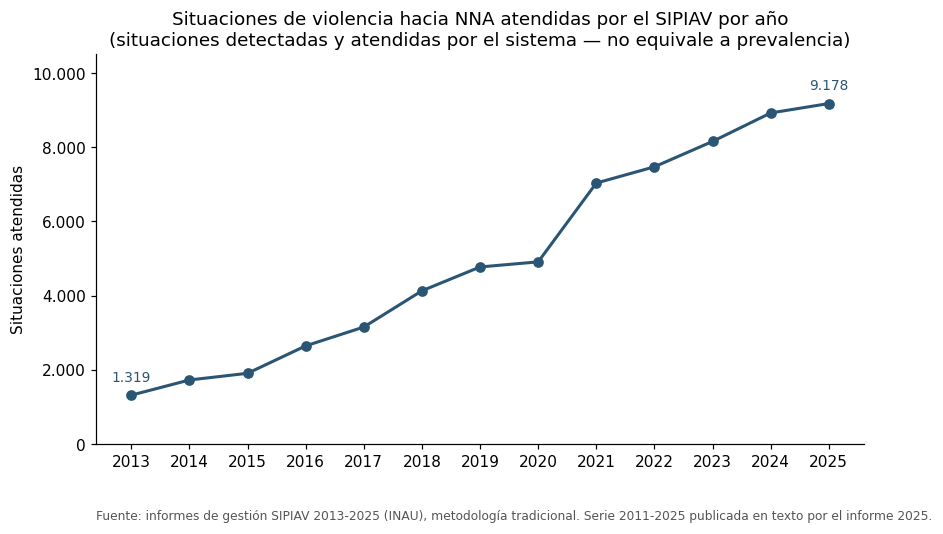

In [2]:
anios, valores = serie_sipiav("situaciones_atendidas")
fig, ax = plt.subplots()
ax.plot(anios, valores, marker="o", color=COLOR, linewidth=2)
ax.set_ylim(0, 10500)
ax.set_xticks(anios)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt(v)))
ax.set_title(
    "Situaciones de violencia hacia NNA atendidas por el SIPIAV por año\n"
    "(situaciones detectadas y atendidas por el sistema — no equivale a prevalencia)"
)
ax.set_ylabel("Situaciones atendidas")
anotar_extremos(ax, anios, valores, COLOR)
fuente(fig, "Fuente: informes de gestión SIPIAV 2013-2025 (INAU), metodología tradicional. "
            "Serie 2011-2025 publicada en texto por el informe 2025.")
plt.show()

**Por qué esta gráfica.** Serie anual de mediciones reales: línea con
marcadores sobre eje temporal en escala real (Cleveland y McGill,
1984), eje vertical desde cero (Healy, 2018) y extremos anotados
(convenciones de gráficas del proyecto).

**Lectura**: las situaciones atendidas se multiplicaron por 7 entre 2013
(1.319) y 2025 (9.178). La serie tiene saltos con explicación
documental: la incorporación del hospital Pereira Rossell como fuente
(2018-2019) y el efecto pospandemia (2021, +43%). Desde 2025 convive una
segunda medición con metodología nueva (7.381) que no forma parte de
esta serie. Por tratarse de un registro administrativo, el crecimiento
describe la expansión de la capacidad de detección y atención tanto como
la evolución del fenómeno.

### Métrica 2. Distribución por sexo de las situaciones, 2013-2025

**¿Qué pregunta responde?** ¿Las situaciones atendidas afectan por igual
a niñas y varones?

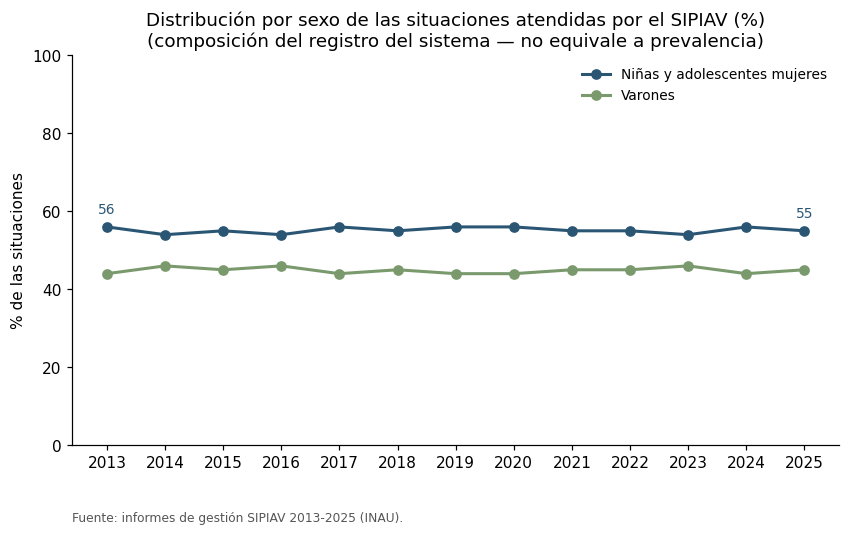

In [3]:
anios_f, fem = serie_sipiav("distribucion_sexo", "Femenino")
fig, ax = plt.subplots()
ax.plot(anios_f, fem, marker="o", color=COLOR, linewidth=2, label="Niñas y adolescentes mujeres")
ax.plot(anios_f, 100 - fem, marker="o", color=PALETA[2], linewidth=2, label="Varones")
ax.set_ylim(0, 100)
ax.set_xticks(anios_f)
ax.set_title(
    "Distribución por sexo de las situaciones atendidas por el SIPIAV (%)\n"
    "(composición del registro del sistema — no equivale a prevalencia)"
)
ax.set_ylabel("% de las situaciones")
ax.legend(frameon=False, fontsize=9)
anotar_extremos(ax, anios_f, fem, COLOR)
fuente(fig, "Fuente: informes de gestión SIPIAV 2013-2025 (INAU).")
plt.show()

**Por qué esta gráfica.** Dos líneas complementarias con eje 0-100:
mantener la escala completa de un porcentaje evita exagerar
fluctuaciones pequeñas (Healy, 2018 — integridad del eje).

**Lectura**: la composición es estable en todo el período: entre 54% y
56% de las situaciones corresponden a niñas y adolescentes mujeres
(55% en 2025). La brecha por sexo es moderada en el total pero — como
muestra la métrica 5 — se concentra de forma extrema en las violencias
sexuales.

### Métrica 3. Distribución por franja etaria, 2013-2025

**¿Qué pregunta responde?** ¿En qué edades se concentran las situaciones
que el sistema atiende?

**Advertencia de fuente**: los tramos publicados cambian a lo largo de la
serie (cinco tramos hasta 2019; el agregado 0-5 desde 2020; publicación
parcial en varios años). La gráfica muestra solo lo publicado con cifra
exacta — los huecos son de la fuente y no se interpolan.

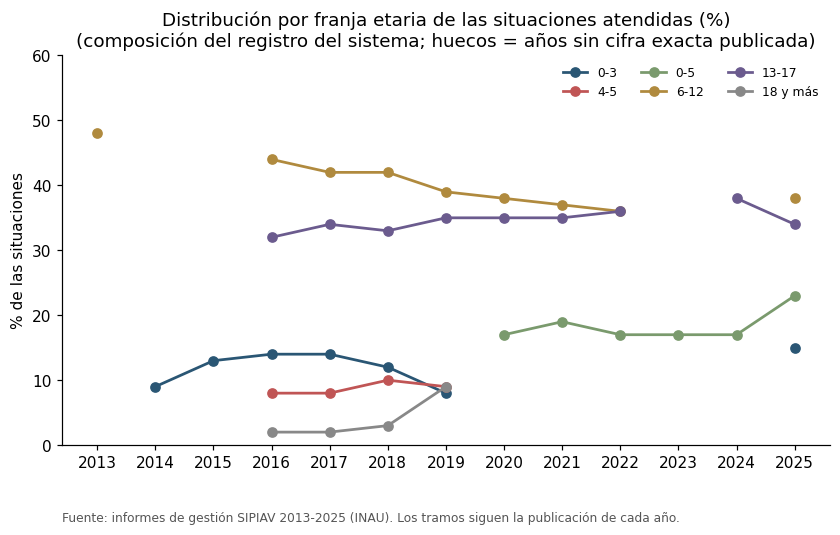

In [4]:
ed = SIP[SIP["metrica"] == "distribucion_edad"]
piv = ed.pivot_table(index="anio", columns="categoria", values="valor")
orden = [c for c in ["0-3", "4-5", "0-5", "6-12", "13-17", "18 y más"] if c in piv.columns]
anios_todos = np.arange(int(piv.index.min()), int(piv.index.max()) + 1)
fig, ax = plt.subplots()
linea_con_huecos(ax, anios_todos, piv[orden])
ax.set_ylim(0, 60)
ax.set_xticks(anios_todos)
ax.set_title(
    "Distribución por franja etaria de las situaciones atendidas (%)\n"
    "(composición del registro del sistema; huecos = años sin cifra exacta publicada)"
)
ax.set_ylabel("% de las situaciones")
ax.legend(frameon=False, fontsize=8, ncol=3)
fuente(fig, "Fuente: informes de gestión SIPIAV 2013-2025 (INAU). Los tramos siguen la publicación de cada año.")
plt.show()

**Por qué esta gráfica.** Líneas con marcadores y huecos visibles: el
marcador distingue la medición real, y la ausencia de línea entre años
sin dato evita inventar continuidad que la fuente no publicó
(convención del proyecto: los cortes no se interpolan).

**Lectura**: las edades escolares concentran el registro: en 2025, 38%
de las situaciones corresponden al tramo 6-12 y 34% al 13-17 (72 de
cada 100 entre ambos). La primera infancia (0-5) representa 23% en 2025,
con un aumento del tramo 0-3 (de 9% en 2024 a 15%) que el propio informe
atribuye a mayor capacidad de detección en esas edades.

### Métrica 4. Tipos de violencia registrados, 2013-2025

**¿Qué pregunta responde?** ¿Qué formas de violencia registra el sistema
y en qué proporción?

**Advertencia de fuente**: la clasificación tiene dos quiebres — en 2020
aparece «explotación sexual» como categoría separada, y desde 2024 abuso
y explotación se fusionan en «violencias sexuales». Las categorías se
grafican tal como las publica cada año, sin empalmar.

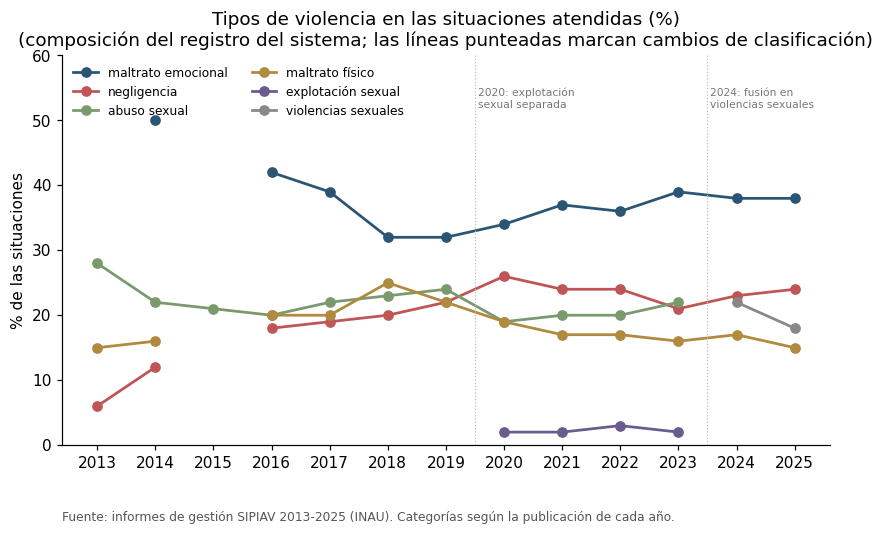

In [5]:
tv = SIP[SIP["metrica"] == "tipo_violencia"]
piv = tv.pivot_table(index="anio", columns="categoria", values="valor")
orden = [c for c in ["maltrato emocional", "negligencia", "abuso sexual",
                     "maltrato físico", "explotación sexual", "violencias sexuales"]
         if c in piv.columns]
anios_todos = np.arange(int(piv.index.min()), int(piv.index.max()) + 1)
fig, ax = plt.subplots()
linea_con_huecos(ax, anios_todos, piv[orden])
for x_q in [2019.5, 2023.5]:
    ax.axvline(x_q, color="#bbbbbb", linewidth=0.8, linestyle=":")
ax.text(2019.55, 52, "2020: explotación\nsexual separada", fontsize=7, color="#777777")
ax.text(2023.55, 52, "2024: fusión en\nviolencias sexuales", fontsize=7, color="#777777")
ax.set_ylim(0, 60)
ax.set_xticks(anios_todos)
ax.set_title(
    "Tipos de violencia en las situaciones atendidas (%)\n"
    "(composición del registro del sistema; las líneas punteadas marcan cambios de clasificación)"
)
ax.set_ylabel("% de las situaciones")
ax.legend(frameon=False, fontsize=8, ncol=2)
fuente(fig, "Fuente: informes de gestión SIPIAV 2013-2025 (INAU). Categorías según la publicación de cada año.")
plt.show()

**Por qué esta gráfica.** Líneas por categoría con los cambios de
clasificación marcados en el propio plano: quien mira solo la gráfica ve
dónde la serie deja de ser comparable (regla central aplicada al plano
visual). Huecos sin interpolar, como en la métrica 3.

**Lectura**: el maltrato emocional es la categoría más frecuente en toda
la serie (entre 32% y 50%; 38% en 2025), seguido por la negligencia
(24% en 2025). Las violencias sexuales representan 18% en 2025 — con la
advertencia de que esa categoría fusiona desde 2024 lo que antes se
publicaba como abuso (20-28%) y explotación (2-3%) por separado.

### Métrica 5. Tipo de violencia por sexo y franja etaria (2025)

**¿Qué pregunta responde?** ¿Las distintas formas de violencia afectan
igual a niñas y varones, y a las distintas edades?

**Advertencia de fuente**: los cruces tipo × sexo y tipo × edad se
publican como tablas en imagen en los informes 2020-2024; se presentan
aquí los valores 2025, publicados en texto y verificados contra la prosa
del informe.

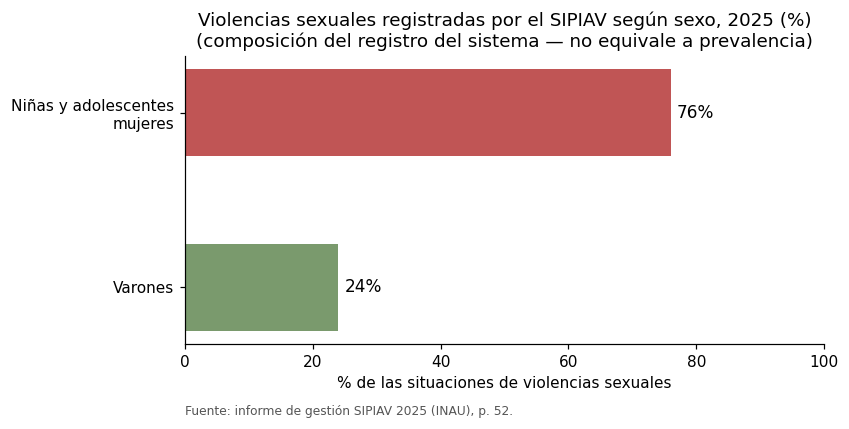

In [6]:
vs = SIP[SIP["metrica"] == "tipo_violencia_sexo"].copy()
vs["sexo"] = vs["categoria"].str.split("|").str[1]
fig, ax = plt.subplots(figsize=(7.5, 3.4))
barras = ax.barh(["Varones", "Niñas y adolescentes\nmujeres"],
                 [float(vs[vs["sexo"] == "Masculino"]["valor"].iloc[0]),
                  float(vs[vs["sexo"] == "Femenino"]["valor"].iloc[0])],
                 color=[PALETA[2], ACENTO], height=0.5)
ax.bar_label(barras, labels=[pct(v, 0) for v in barras.datavalues], padding=4, fontsize=11)
ax.set_xlim(0, 100)
ax.set_title(
    "Violencias sexuales registradas por el SIPIAV según sexo, 2025 (%)\n"
    "(composición del registro del sistema — no equivale a prevalencia)"
)
ax.set_xlabel("% de las situaciones de violencias sexuales")
fuente(fig, "Fuente: informe de gestión SIPIAV 2025 (INAU), p. 52.", y=-0.08)
plt.show()

**Por qué esta gráfica.** Dos barras horizontales bastan: la comparación
de longitudes desde base común es la percepción visual más precisa
(Cleveland y McGill, 1984), y agregar categorías sin cifra exacta
publicada violaría la regla de no consignar valores dudosos.

**Lectura**: de cada cuatro situaciones de violencias sexuales, tres
corresponden a niñas y adolescentes mujeres (76% frente a 24%). Es
además el único tipo de violencia con más de la mitad de los registros
concentrados en una sola franja: 51% en el tramo 13-17. Los otros tres
tipos se reparten de forma pareja por sexo (proporciones cercanas al
50%, según el informe) y son modales en el tramo 6-12 (maltrato
emocional 37%, maltrato físico 38%, negligencia 42%). La violencia
sexual registrada tiene un patrón específico: adolescente y de género.

### Métrica 6. Recurrencia: episodio único o violencia reiterada

**¿Qué pregunta responde?** ¿El sistema detecta la violencia ante el
primer episodio o cuando ya se repitió?

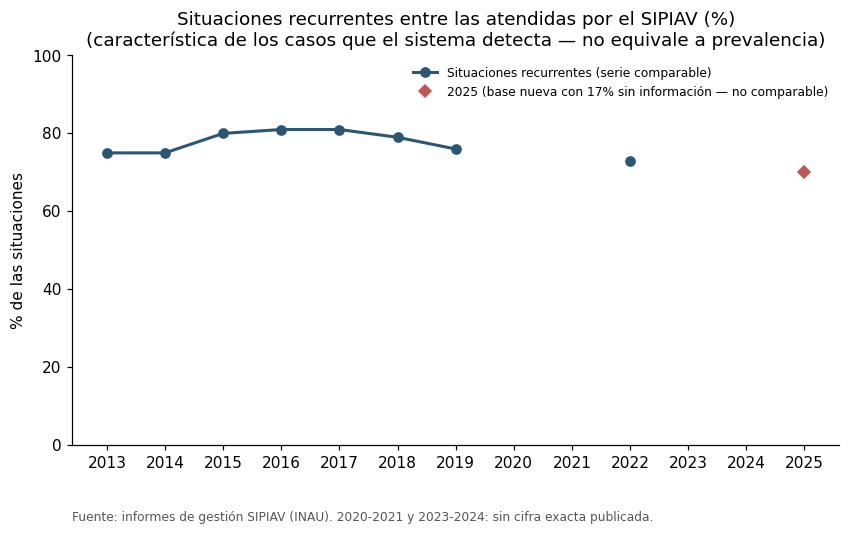

In [7]:
rec = SIP[(SIP["metrica"] == "recurrencia") & (SIP["categoria"] == "recurrente")].sort_values("anio")
comp = rec[rec["anio"] <= 2024]
p25 = rec[rec["anio"] == 2025]
fig, ax = plt.subplots()
anios_todos = np.arange(2013, 2026)
y = comp.set_index("anio")["valor"].reindex(anios_todos)
ax.plot(anios_todos, y, marker="o", color=COLOR, linewidth=2, label="Situaciones recurrentes (serie comparable)")
if len(p25):
    ax.plot(p25["anio"], p25["valor"], marker="D", color=ACENTO, linestyle="none",
            label="2025 (base nueva con 17% sin información — no comparable)")
ax.set_ylim(0, 100)
ax.set_xticks(anios_todos)
ax.set_title(
    "Situaciones recurrentes entre las atendidas por el SIPIAV (%)\n"
    "(característica de los casos que el sistema detecta — no equivale a prevalencia)"
)
ax.set_ylabel("% de las situaciones")
ax.legend(frameon=False, fontsize=8)
fuente(fig, "Fuente: informes de gestión SIPIAV (INAU). 2020-2021 y 2023-2024: sin cifra exacta publicada.")
plt.show()

**Por qué esta gráfica.** Línea para la serie comparable y **punto
suelto con marcador distinto** para 2025: el cambio de base de cálculo
(la fuente incorpora 17% de casos «sin información» a la base) hace que
unirlo con una línea inventaría una caída que no se midió
(convención del proyecto: los cortes se dibujan como puntos sueltos).

**Lectura**: en toda la serie comparable, entre 73% y 81% de las
situaciones ya eran recurrentes al ser detectadas — el sistema suele
llegar cuando la violencia ya se repitió. El 70% de 2025 no es
comparable por el cambio de base (sobre los casos con dato equivale a
84%).

### Métrica 7. Cronicidad: violencia sostenida en el tiempo

**¿Qué pregunta responde?** ¿Qué proporción de las situaciones
detectadas lleva más de seis meses de violencia sostenida?

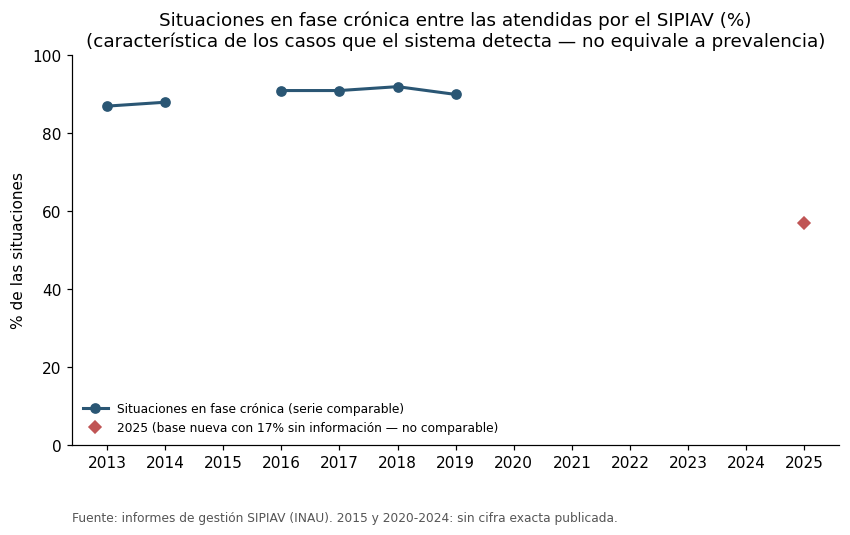

In [8]:
cro = SIP[(SIP["metrica"] == "cronicidad") & (SIP["categoria"] == "fase crónica")].sort_values("anio")
comp = cro[cro["anio"] <= 2024]
p25 = cro[cro["anio"] == 2025]
fig, ax = plt.subplots()
anios_todos = np.arange(2013, 2026)
y = comp.set_index("anio")["valor"].reindex(anios_todos)
ax.plot(anios_todos, y, marker="o", color=COLOR, linewidth=2, label="Situaciones en fase crónica (serie comparable)")
if len(p25):
    ax.plot(p25["anio"], p25["valor"], marker="D", color=ACENTO, linestyle="none",
            label="2025 (base nueva con 17% sin información — no comparable)")
ax.set_ylim(0, 100)
ax.set_xticks(anios_todos)
ax.set_title(
    "Situaciones en fase crónica entre las atendidas por el SIPIAV (%)\n"
    "(característica de los casos que el sistema detecta — no equivale a prevalencia)"
)
ax.set_ylabel("% de las situaciones")
ax.legend(frameon=False, fontsize=8)
fuente(fig, "Fuente: informes de gestión SIPIAV (INAU). 2015 y 2020-2024: sin cifra exacta publicada.")
plt.show()

**Por qué esta gráfica.** Misma convención que la métrica 6: serie
comparable en línea, punto 2025 suelto por cambio de base.

**Lectura**: en la serie comparable, alrededor de 9 de cada 10
situaciones detectadas ya estaban en fase crónica (87-92%). Junto con la
recurrencia, ambas métricas cuentan la misma historia: la detección
suele ser tardía. El 57% de 2025 no es comparable (base con 17% sin
información y 26% en etapa de inicio — si la mejora en detección
temprana que sugiere se confirma cuando la base se estabilice, sería un
cambio sustantivo).

### Métrica 8. Vínculo de la persona agresora con el NNA

**¿Qué pregunta responde?** ¿Quién ejerce la violencia que el sistema
registra?

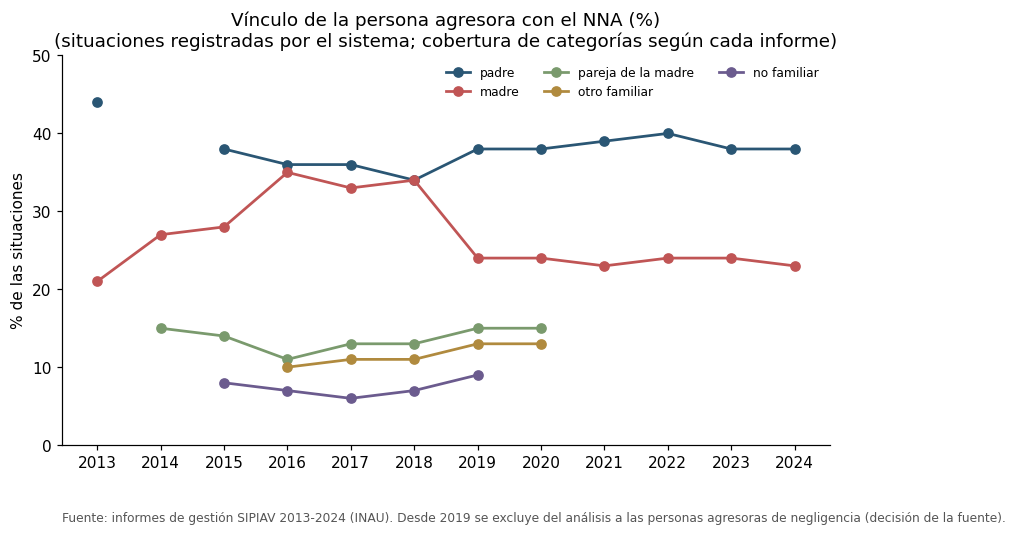

In [9]:
ag = SIP[SIP["metrica"] == "agresor_vinculo"]
piv = ag.pivot_table(index="anio", columns="categoria", values="valor")
orden = [c for c in ["padre", "madre", "pareja de la madre", "otro familiar", "no familiar"] if c in piv.columns]
anios_todos = np.arange(2013, 2025)
fig, ax = plt.subplots()
linea_con_huecos(ax, anios_todos, piv[orden])
ax.set_ylim(0, 50)
ax.set_xticks(anios_todos)
ax.set_title(
    "Vínculo de la persona agresora con el NNA (%)\n"
    "(situaciones registradas por el sistema; cobertura de categorías según cada informe)"
)
ax.set_ylabel("% de las situaciones")
ax.legend(frameon=False, fontsize=8, ncol=3)
fuente(fig, "Fuente: informes de gestión SIPIAV 2013-2024 (INAU). Desde 2019 se excluye del análisis "
            "a las personas agresoras de negligencia (decisión de la fuente).")
plt.show()

**Por qué esta gráfica.** Líneas por categoría con huecos sin
interpolar: la cobertura de categorías se reduce desde 2020 porque los
gráficos de los informes dejan de ser extraíbles (documentado en las
notas de curaduría del proyecto).

**Lectura**: la violencia registrada ocurre dentro del entorno del NNA:
alrededor de 9 de cada 10 personas agresoras son familiares directos o
integran el núcleo de convivencia (91-94% en los años con cifra exacta).
El padre (34-44%) y la madre (21-35%) encabezan la distribución en toda
la serie. Desde 2019 la fuente excluye la negligencia de este análisis,
por lo que los valores posteriores no son estrictamente comparables con
2013-2018.

### Métrica 9. NNA que visualizan la violencia que sufren

**¿Qué pregunta responde?** ¿Qué proporción de los NNA atendidos
reconoce la situación de violencia que atraviesa?

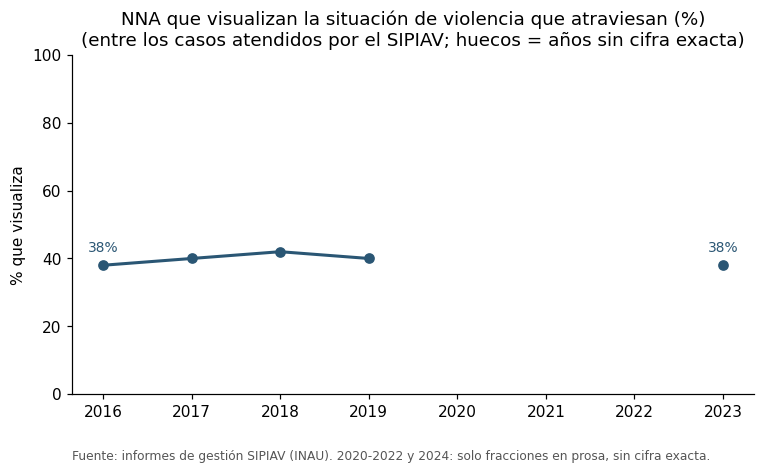

In [10]:
vis = SIP[(SIP["metrica"] == "visualizacion") & (SIP["categoria"] == "visualiza")].sort_values("anio")
anios_todos = np.arange(2016, 2024)
y = vis.set_index("anio")["valor"].reindex(anios_todos)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(anios_todos, y, marker="o", color=COLOR, linewidth=2)
ax.set_ylim(0, 100)
ax.set_xticks(anios_todos)
ax.set_title(
    "NNA que visualizan la situación de violencia que atraviesan (%)\n"
    "(entre los casos atendidos por el SIPIAV; huecos = años sin cifra exacta)"
)
ax.set_ylabel("% que visualiza")
ax.annotate(pct(float(y.dropna().iloc[0]), 0), (2016, float(y.dropna().iloc[0])),
            textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9, color=COLOR)
ax.annotate(pct(float(y.dropna().iloc[-1]), 0), (2023, float(y.dropna().iloc[-1])),
            textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9, color=COLOR)
fuente(fig, "Fuente: informes de gestión SIPIAV (INAU). 2020-2022 y 2024: solo fracciones en prosa, sin cifra exacta.")
plt.show()

**Por qué esta gráfica.** Serie corta con huecos de la fuente: línea con
marcadores solo donde hay medición publicada con cifra exacta.

**Lectura**: solo alrededor de 4 de cada 10 NNA atendidos visualiza la
violencia que sufre (38-42% en los años con dato; 38% en 2023). La
naturalización de la violencia por sus propias víctimas es uno de los
obstáculos de detección que la fuente documenta de forma consistente.

### Métrica 10. Inclusión de la familia en la intervención

**¿Qué pregunta responde?** ¿En qué proporción de las intervenciones se
logra incorporar a la familia como parte del abordaje?

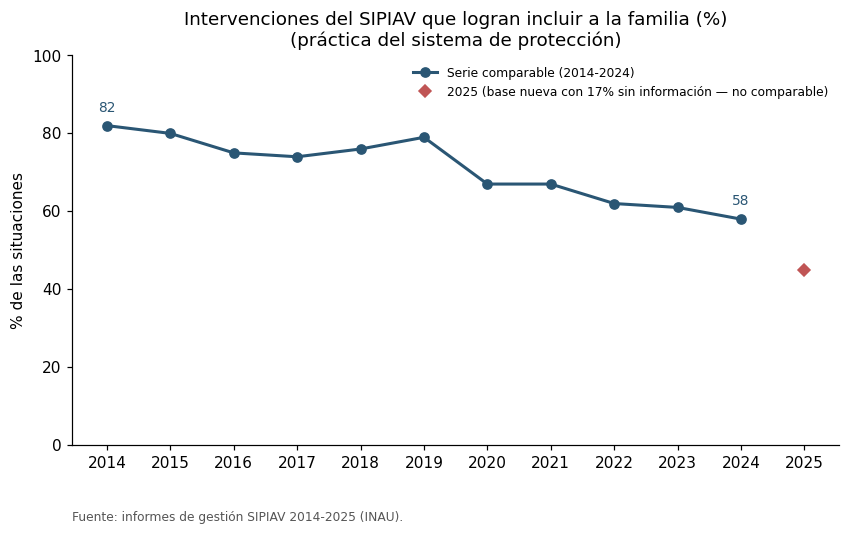

In [11]:
inc = SIP[(SIP["metrica"] == "inclusion_familia") & (SIP["categoria"] == "incluye familia")].sort_values("anio")
comp = inc[inc["anio"] <= 2024]
p25 = inc[inc["anio"] == 2025]
fig, ax = plt.subplots()
ax.plot(comp["anio"], comp["valor"], marker="o", color=COLOR, linewidth=2,
        label="Serie comparable (2014-2024)")
if len(p25):
    ax.plot(p25["anio"], p25["valor"], marker="D", color=ACENTO, linestyle="none",
            label="2025 (base nueva con 17% sin información — no comparable)")
ax.set_ylim(0, 100)
ax.set_xticks(np.arange(2014, 2026))
ax.set_title(
    "Intervenciones del SIPIAV que logran incluir a la familia (%)\n"
    "(práctica del sistema de protección)"
)
ax.set_ylabel("% de las situaciones")
ax.legend(frameon=False, fontsize=8)
anotar_extremos(ax, comp["anio"].to_numpy(), comp["valor"].to_numpy(), COLOR)
fuente(fig, "Fuente: informes de gestión SIPIAV 2014-2025 (INAU).")
plt.show()

**Por qué esta gráfica.** Serie comparable en línea y 2025 como punto
suelto: el informe 2025 calcula esta proporción sobre una base que
incluye 17% de casos sin información, incompatible con la serie
histórica.

**Lectura**: la serie comparable muestra un deterioro sostenido y
sustantivo: la familia se incluía en 82% de las intervenciones en 2014 y
en 58% en 2024 — 24 puntos porcentuales menos en una década. Es la serie
con la lectura más preocupante del tema, porque describe la práctica del
propio sistema, no la demanda que recibe. El 45% publicado para 2025 no
es comparable (sobre los casos con dato equivale a 54%).

### Métrica 11. Cobertura territorial: Comités de Recepción Local

**¿Qué pregunta responde?** ¿Con cuántos dispositivos territoriales de
recepción de situaciones cuenta el sistema?

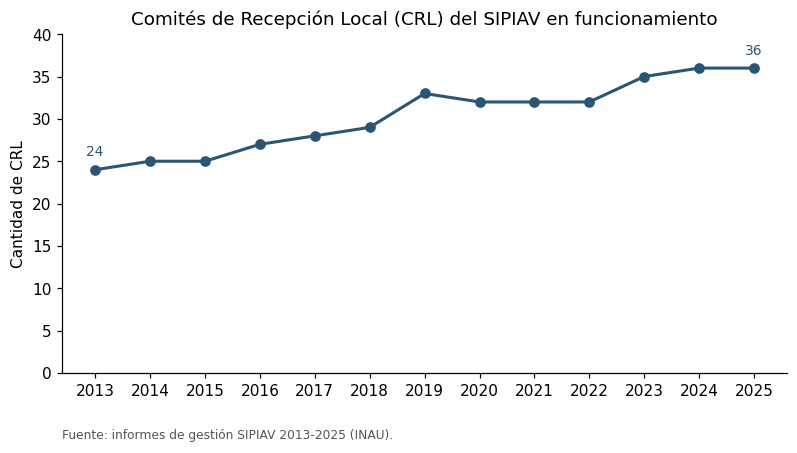

In [12]:
anios_c, crl = serie_sipiav("crl_cantidad")
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(anios_c, crl, marker="o", color=COLOR, linewidth=2)
ax.set_ylim(0, 40)
ax.set_xticks(anios_c)
ax.set_title("Comités de Recepción Local (CRL) del SIPIAV en funcionamiento")
ax.set_ylabel("Cantidad de CRL")
anotar_extremos(ax, anios_c, crl, COLOR)
fuente(fig, "Fuente: informes de gestión SIPIAV 2013-2025 (INAU).")
plt.show()

**Por qué esta gráfica.** Serie anual de un conteo institucional: línea
con marcadores, eje desde cero.

**Lectura**: la red pasó de 24 CRL en 2013 a 36 desde 2024 (estable en
2025). La expansión no fue monótona — 33 en 2019, 32 entre 2020 y
2022 — y muestra desaceleración: la cobertura parece acercarse a su
techo territorial (los 36 CRL cubren las principales localidades del
país) — por eso su proyección (P5, al cierre de este tema) se lee como
orden de magnitud, no como cronograma de aperturas.

### Proyección P1. Situaciones que atendería el sistema, 2026-2027 — con validación 2025

**¿Qué pregunta responde?** Si la tendencia observada continúa, ¿cuántas
situaciones atendería el sistema en los próximos años? ¿Y qué pasó
cuando la primera proyección se contrastó con el dato real?

**Término** — **escenario inercial**: proyección de la continuación de
la tendencia observada, bajo el supuesto explícito de que las
condiciones actuales persisten. No predice cuánta violencia habrá: es la
trayectoria del propio sistema si nada cambia.

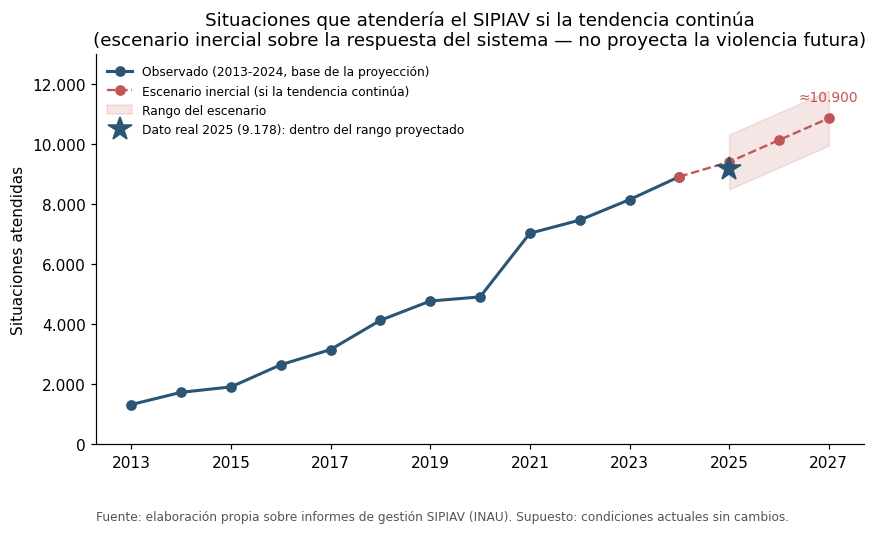

In [13]:
# La proyección publicada en la versión anterior del informe se calculó con la serie
# 2013-2024. El informe 2025 (9.178) quedó dentro del rango publicado
# 8.500-10.300: la proyección se muestra junto con el dato real que la
# validó, y se extiende con el mismo método (justificación técnica y
# backtest en docs/PREDICTIVO_JUSTIFICACION_TECNICA.md).
anios, valores = serie_sipiav("situaciones_atendidas")
base = anios <= 2024
coef = np.polyfit(anios[base], valores[base], 1)
residuos = valores[base] - np.polyval(coef, anios[base])
s = residuos.std(ddof=2)
anios_fut = np.arange(2025, 2028)
proy = np.polyval(coef, anios_fut)

fig, ax = plt.subplots()
ax.plot(anios[base], valores[base], marker="o", color=COLOR, linewidth=2,
        label="Observado (2013-2024, base de la proyección)")
ax.plot(np.append(anios[base][-1], anios_fut), np.append(valores[base][-1], proy),
        marker="o", linestyle="--", color=ACENTO,
        label="Escenario inercial (si la tendencia continúa)")
ax.fill_between(anios_fut, proy - 2 * s, proy + 2 * s, color=ACENTO, alpha=0.15,
                label="Rango del escenario")
ax.plot([2025], [valores[anios == 2025][0]], marker="*", markersize=16, color=COLOR,
        linestyle="none", label="Dato real 2025 (9.178): dentro del rango proyectado")
ax.set_ylim(0, 13000)
ax.set_xticks(np.arange(2013, 2028, 2))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt(v)))
ax.set_title(
    "Situaciones que atendería el SIPIAV si la tendencia continúa\n"
    "(escenario inercial sobre la respuesta del sistema — no proyecta la violencia futura)"
)
ax.set_ylabel("Situaciones atendidas")
ax.legend(frameon=False, fontsize=8)
ax.annotate("≈" + fmt(round(proy[-1], -2)), (anios_fut[-1], proy[-1]),
            textcoords="offset points", xytext=(0, 11), ha="center", fontsize=9, color=ACENTO)
fuente(fig, "Fuente: elaboración propia sobre informes de gestión SIPIAV (INAU). Supuesto: condiciones actuales sin cambios.")
plt.show()

**Por qué esta gráfica.** Proyección como continuación punteada con
banda de rango (nunca un número único), y el dato real 2025 superpuesto
con marcador propio: la validación fuera de muestra se muestra, no solo
se declara (regla metodológica del proyecto).

**Lectura**: la proyección publicada antes de conocerse el dato 2025
(entre 8.500 y 10.300 situaciones) quedó **validada**: el real fue
9.178. Si la tendencia continúa, el sistema atendería entre 9.200 y
11.100 situaciones en 2026, y entre 10.000 y 11.800 en 2027. Advertencia
para el próximo ciclo: si SIPIAV migra su serie a la nueva metodología,
esta proyección deberá recalcularse sobre la base nueva.

### Proyección P2. Inclusión de la familia proyectada, 2025-2027

**¿Qué pregunta responde?** Si el deterioro observado en la métrica 10
continúa, ¿a qué proporción llegaría la inclusión familiar?

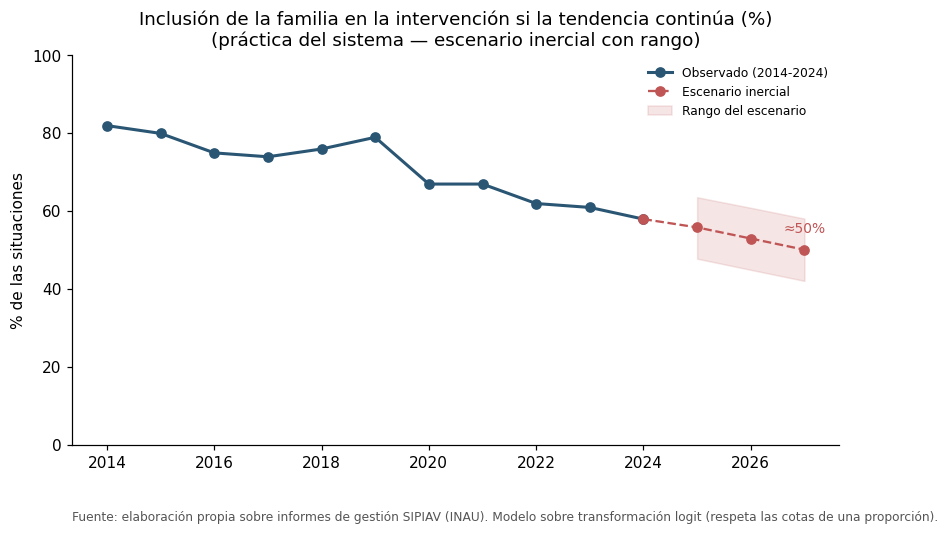

In [14]:
inc = SIP[(SIP["metrica"] == "inclusion_familia") & (SIP["categoria"] == "incluye familia")].sort_values("anio")
comp = inc[inc["anio"] <= 2024]
t = comp["anio"].to_numpy(dtype=float)
y = comp["valor"].to_numpy(dtype=float)

def logit(p):
    p = np.clip(p / 100, 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p))

def inv_logit(z):
    return 100 / (1 + np.exp(-z))

c = np.polyfit(t, logit(y), 1)
res = logit(y) - np.polyval(c, t)
s = res.std(ddof=2)
t_fut = np.arange(2025, 2028, dtype=float)
z = np.polyval(c, t_fut)
proy, bajo, alto = inv_logit(z), inv_logit(z - 2 * s), inv_logit(z + 2 * s)

fig, ax = plt.subplots()
ax.plot(t, y, marker="o", color=COLOR, linewidth=2, label="Observado (2014-2024)")
ax.plot(np.append(t[-1], t_fut), np.append(y[-1], proy), marker="o", linestyle="--",
        color=ACENTO, label="Escenario inercial")
ax.fill_between(t_fut, bajo, alto, color=ACENTO, alpha=0.15, label="Rango del escenario")
ax.set_ylim(0, 100)
ax.set_xticks(np.arange(2014, 2028, 2))
ax.set_title(
    "Inclusión de la familia en la intervención si la tendencia continúa (%)\n"
    "(práctica del sistema — escenario inercial con rango)"
)
ax.set_ylabel("% de las situaciones")
ax.legend(frameon=False, fontsize=8)
ax.annotate("≈" + pct(proy[-1], 0), (t_fut[-1], proy[-1]),
            textcoords="offset points", xytext=(0, 11), ha="center", fontsize=9, color=ACENTO)
fuente(fig, "Fuente: elaboración propia sobre informes de gestión SIPIAV (INAU). "
            "Modelo sobre transformación logit (respeta las cotas de una proporción).")
plt.show()

**Por qué esta gráfica.** Misma convención que P1. El modelo se ajusta
sobre la transformación logit para que la proyección de una proporción
nunca salga del rango 0-100 (Hyndman y Athanasopoulos, FPP3 —
justificación técnica en el repositorio).

**Lectura**: si la tendencia 2014-2024 continúa, hacia 2027 la familia
se incluiría en aproximadamente la mitad de las intervenciones (50%,
rango 42-58) — cuando en 2014 se lograba en más de 8 de cada 10. La
validación con el dato 2025 quedó **no concluyente** por el cambio de
base de la fuente (el 45% publicado no es comparable; sobre los casos
con dato, 54%, dentro del rango proyectado 48-64): el modelo no se
re-estima hasta que la base se estabilice.

### Proyección P5. Cobertura territorial proyectada, 2026-2028

**¿Qué pregunta responde?** Si el ritmo de aperturas de la métrica 11
continúa, ¿cuántos Comités de Recepción Local tendría el sistema en los
próximos años?

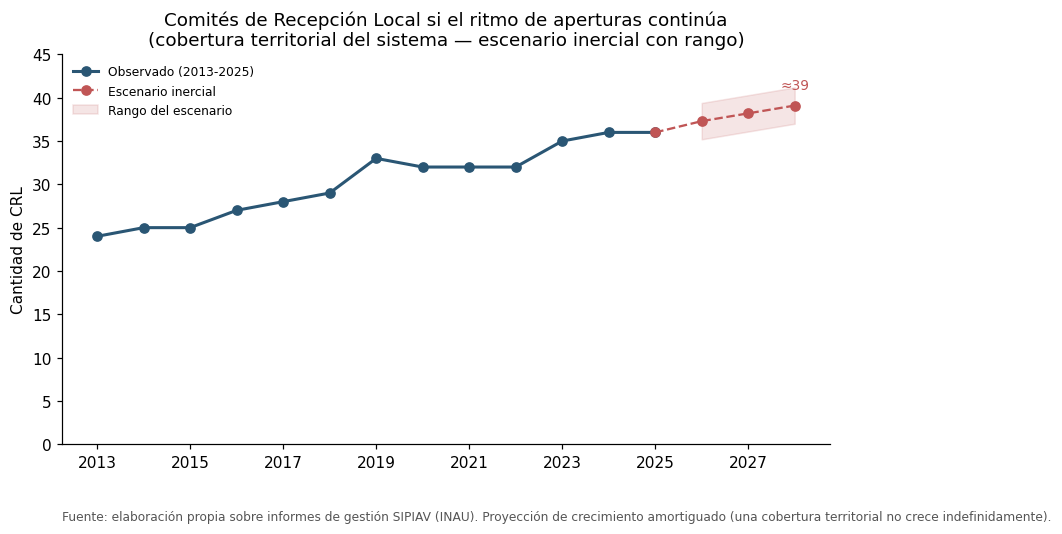

In [15]:
P5C = pd.read_csv(RESULTADOS / "proyecciones" / "p5_cobertura_crl.csv")
obs5 = P5C[P5C["tipo"] == "observado"]
proy5 = P5C[P5C["tipo"] == "proyectado"]
rango5 = proy5["rango"].str.split("-", expand=True).astype(float)

fig, ax = plt.subplots()
ax.plot(obs5["anio"], obs5["crl"], marker="o", color=COLOR, linewidth=2,
        label="Observado (2013-2025)")
ax.plot(np.append(obs5["anio"].iloc[-1], proy5["anio"]),
        np.append(obs5["crl"].iloc[-1], proy5["crl"]), marker="o", linestyle="--",
        color=ACENTO, label="Escenario inercial")
ax.fill_between(proy5["anio"], rango5[0], rango5[1], color=ACENTO, alpha=0.15,
                label="Rango del escenario")
ax.set_ylim(0, 45)
ax.set_xticks(np.arange(2013, 2029, 2))
ax.set_title(
    "Comités de Recepción Local si el ritmo de aperturas continúa\n"
    "(cobertura territorial del sistema — escenario inercial con rango)"
)
ax.set_ylabel("Cantidad de CRL")
ax.legend(frameon=False, fontsize=8)
ax.annotate("≈" + fmt(proy5["crl"].iloc[-1]), (proy5["anio"].iloc[-1], proy5["crl"].iloc[-1]),
            textcoords="offset points", xytext=(0, 11), ha="center", fontsize=9, color=ACENTO)
fuente(fig, "Fuente: elaboración propia sobre informes de gestión SIPIAV (INAU). "
            "Proyección de crecimiento amortiguado (una cobertura territorial no crece indefinidamente).")
plt.show()

**Por qué esta gráfica.** Misma convención que P1 y P2: serie observada
en línea continua, escenario inercial punteado con su rango sombreado y
eje desde cero (Healy, 2018). La proyección crece de forma amortiguada —
la cobertura de un territorio finito no crece indefinidamente
(justificación técnica en el repositorio).

**Lectura**: de seguir el ritmo de aperturas, el sistema sumaría unos
tres comités hacia 2028 (39, rango 37-41), sobre los 36 actuales. La
serie crece a saltos administrativos (mesetas de dos o tres años entre
tandas de apertura), así que la lectura útil es el orden de magnitud —
la cobertura seguiría expandiéndose lentamente — y no el año exacto de
cada apertura.

## Tema 2 — Explotación sexual de NNA (CONAPEES, Fiscalía)

Registros administrativos con una advertencia adicional: la explotación
sexual tiene un **subregistro reconocido por el propio comité** — las
cifras describen la actividad de los servicios que la detectan, con
mayor distancia aún respecto del fenómeno real. El dato cuantitativo
sistematizado vive en el estudio FLACSO 2023 (capítulo 6), que compila
las cifras oficiales de CONAPEES y Fiscalía.

**Vacío documentado**: no hay serie oficial de situaciones 2022 en
adelante — el III Plan Nacional 2023-2028 (descargado y revisado) no la
trae, y las cifras difundidas por prensa (285 y 456) no son conciliables
entre sí sin conocer año y definición exacta.

### Métrica 12. Situaciones de explotación sexual atendidas (CONAPEES), 2018-2021

**¿Qué pregunta responde?** ¿Cuántas situaciones de explotación sexual
hacia NNA atendió por año el sistema especializado?

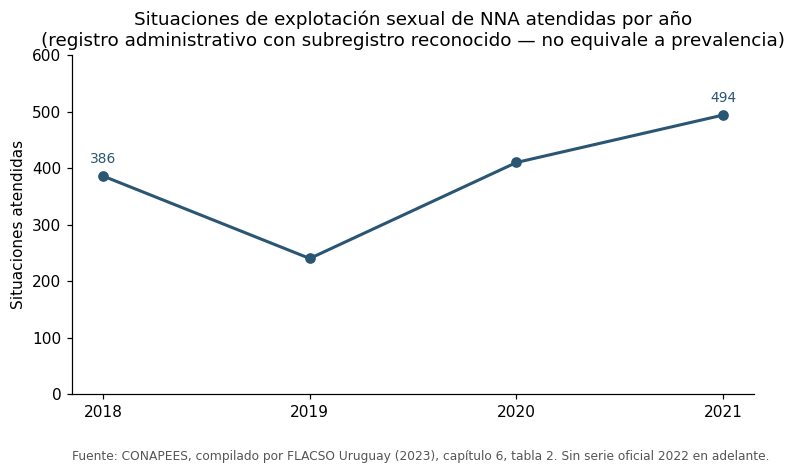

In [16]:
tot = CONA[(CONA["departamento"] == "Total nacional") &
           (CONA["nota"].str.contains("total situaciones", na=False))].sort_values("anio")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tot["anio"], tot["valor"], marker="o", color=COLOR, linewidth=2)
ax.set_ylim(0, 600)
ax.set_xticks(tot["anio"])
ax.set_title(
    "Situaciones de explotación sexual de NNA atendidas por año\n"
    "(registro administrativo con subregistro reconocido — no equivale a prevalencia)"
)
ax.set_ylabel("Situaciones atendidas")
anotar_extremos(ax, tot["anio"].to_numpy(), tot["valor"].to_numpy(), COLOR)
fuente(fig, "Fuente: CONAPEES, compilado por FLACSO Uruguay (2023), capítulo 6, tabla 2. "
            "Sin serie oficial 2022 en adelante.")
plt.show()

**Por qué esta gráfica.** Serie corta de 4 mediciones reales: línea con
marcadores; no se proyecta (menos de 6 puntos, regla del bloque
predictivo — P7 descartada por esa razón).

**Lectura**: entre 240 y 494 situaciones anuales atendidas (2018-2021),
con caída en 2019 y crecimiento posterior. La fuente incluye la apertura
por los 19 departamentos (todos registran casos, todos los años). La
serie termina en 2021: la ausencia de cifras oficiales posteriores es el
vacío de información principal del tema.

### Métrica 13. Sexo de las víctimas de explotación sexual, 2020-2021

**¿Qué pregunta responde?** ¿A quiénes afecta la explotación sexual que
el sistema detecta?

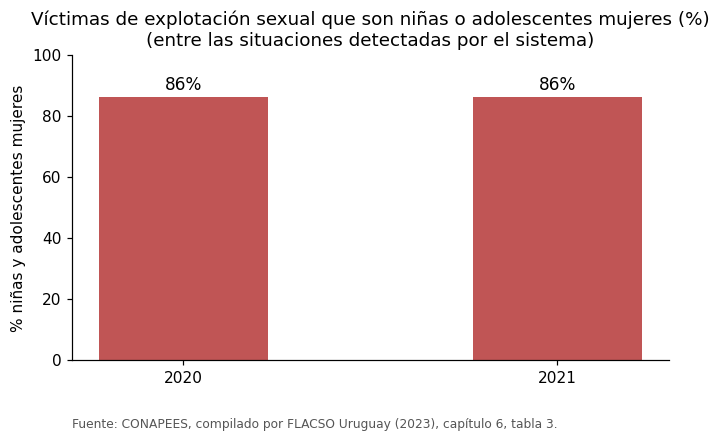

In [17]:
ts = CONA_SEXO[CONA_SEXO["departamento"] == "Total nacional"].sort_values("anio")
fig, ax = plt.subplots(figsize=(7, 3.6))
barras = ax.bar([str(a) for a in ts["anio"]], ts["pct_mujeres"], color=ACENTO, width=0.45)
ax.bar_label(barras, labels=[pct(v, 0) for v in ts["pct_mujeres"]], padding=3, fontsize=11)
ax.set_ylim(0, 100)
ax.set_title(
    "Víctimas de explotación sexual que son niñas o adolescentes mujeres (%)\n"
    "(entre las situaciones detectadas por el sistema)"
)
ax.set_ylabel("% niñas y adolescentes mujeres")
fuente(fig, "Fuente: CONAPEES, compilado por FLACSO Uruguay (2023), capítulo 6, tabla 3.", y=-0.06)
plt.show()

**Por qué esta gráfica.** Dos barras con el valor anotado: para dos
mediciones puntuales, la barra comunica el nivel sin sugerir tendencia.

**Lectura**: 86% de las víctimas identificadas son niñas y adolescentes
mujeres en ambos años con dato. El sesgo de género es aún más marcado
que en las violencias sexuales del SIPIAV (76%) — consistente con la
especificidad de género de este tipo de violencia.

### Métrica 14. Explotación sexual dentro del registro del SIPIAV

**¿Qué pregunta responde?** ¿Qué lugar ocupa la explotación sexual entre
los tipos de violencia que registra el sistema general de protección?

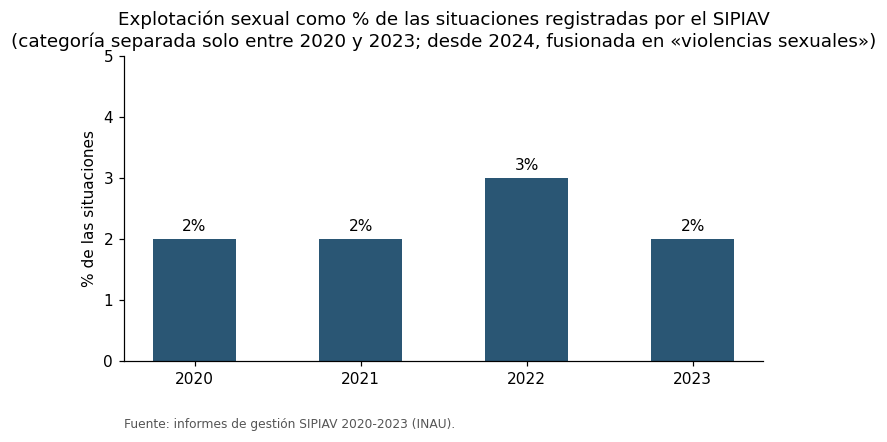

In [18]:
es = SIP[(SIP["metrica"] == "tipo_violencia") & (SIP["categoria"] == "explotación sexual")].sort_values("anio")
fig, ax = plt.subplots(figsize=(7.5, 3.6))
barras = ax.bar([str(a) for a in es["anio"]], es["valor"], color=COLOR, width=0.5)
ax.bar_label(barras, labels=[pct(v, 0) for v in es["valor"]], padding=3, fontsize=10)
ax.set_ylim(0, 5)
ax.set_title(
    "Explotación sexual como % de las situaciones registradas por el SIPIAV\n"
    "(categoría separada solo entre 2020 y 2023; desde 2024, fusionada en «violencias sexuales»)"
)
ax.set_ylabel("% de las situaciones")
fuente(fig, "Fuente: informes de gestión SIPIAV 2020-2023 (INAU).", y=-0.06)
plt.show()

**Por qué esta gráfica.** Barras para una ventana corta de 4 años: la
categoría existió como tal solo entre 2020 y 2023, y graficarla como
serie continua sugeriría una historia más larga que la real.

**Lectura**: la explotación sexual representó 2-3% de las situaciones
registradas por el SIPIAV mientras existió como categoría separada — en
valores absolutos, 98 casos en 2020 y 140 en 2021 según la compilación
de FLACSO. Desde 2024 quedó fusionada en «violencias sexuales», por lo
que esta ventana de visibilidad estadística se cerró: hoy ninguna fuente
pública permite seguir la explotación sexual como categoría propia.

### Métrica 15. Actuaciones de Fiscalía por delitos sexuales con víctima NNA, 2018-2021

**¿Qué pregunta responde?** ¿Cuántas actuaciones penales por delitos
sexuales contra NNA inicia el sistema de justicia por año?

**Precisión de alcance**: son delitos sexuales con víctima NNA en
general (no solo explotación) — se rotula así, siguiendo la regla de
misma métrica, misma definición.

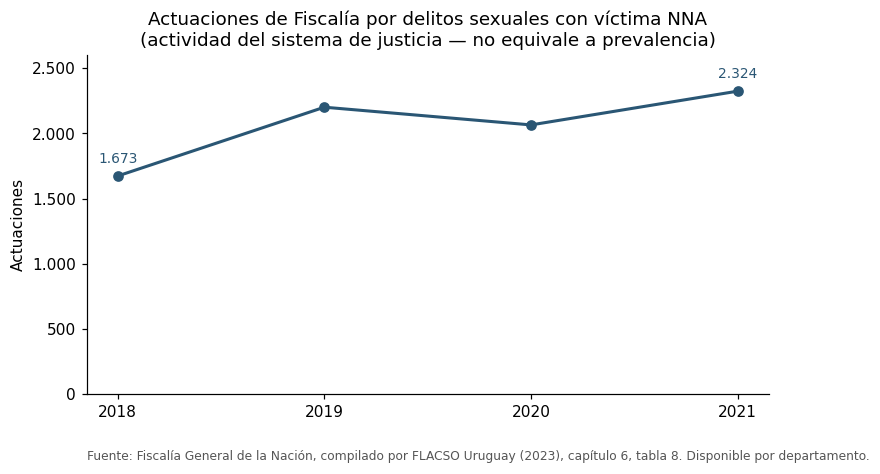

In [19]:
tf = FISC[FISC["departamento"] == "Total nacional"].sort_values("anio")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tf["anio"], tf["valor"], marker="o", color=COLOR, linewidth=2)
ax.set_ylim(0, 2600)
ax.set_xticks(tf["anio"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt(v)))
ax.set_title(
    "Actuaciones de Fiscalía por delitos sexuales con víctima NNA\n"
    "(actividad del sistema de justicia — no equivale a prevalencia)"
)
ax.set_ylabel("Actuaciones")
anotar_extremos(ax, tf["anio"].to_numpy(), tf["valor"].to_numpy(), COLOR)
fuente(fig, "Fuente: Fiscalía General de la Nación, compilado por FLACSO Uruguay (2023), capítulo 6, tabla 8. "
            "Disponible por departamento.")
plt.show()

**Por qué esta gráfica.** Serie corta de conteos: línea con marcadores,
eje desde cero.

**Lectura**: entre 1.673 (2018) y 2.324 (2021) actuaciones anuales — un
orden de magnitud cuatro veces mayor que las situaciones que atiende el
sistema especializado en explotación (métrica 12), lo que dimensiona
cuánta violencia sexual hacia NNA llega al sistema penal. La fuente
permite la apertura departamental y en tasa cada 10.000 NNA, reservada
para el análisis territorial.

## Tema 3 — Trabajo infantil (ENSANNA 2024, ENTI 2010, ECH)

Este tema combina la única fuente de **prevalencia** disponible — la
ENSANNA 2024 (encuesta con diseño muestral del INE/MTSS, con apoyo de
OIT y UNICEF) — con su antecedente 2010 y con el cálculo propio sobre la
ECH para trabajo adolescente.

Términos utilizados:

- **Trabajo infantil**: definición estadística alineada con los
  Convenios 138 y 182 de la OIT (universo ENSANNA: 5 a 17 años).
- **TFP / TNRS**: trabajo en actividades económicas (frontera de
  producción) y trabajo no remunerado de servicios del hogar en
  condiciones no permitidas, respectivamente.

### Métrica 16. Tasa y volumen de trabajo infantil, 2024

**¿Qué pregunta responde?** ¿Qué proporción de NNA está en situación de
trabajo infantil y cómo cambia con la edad?

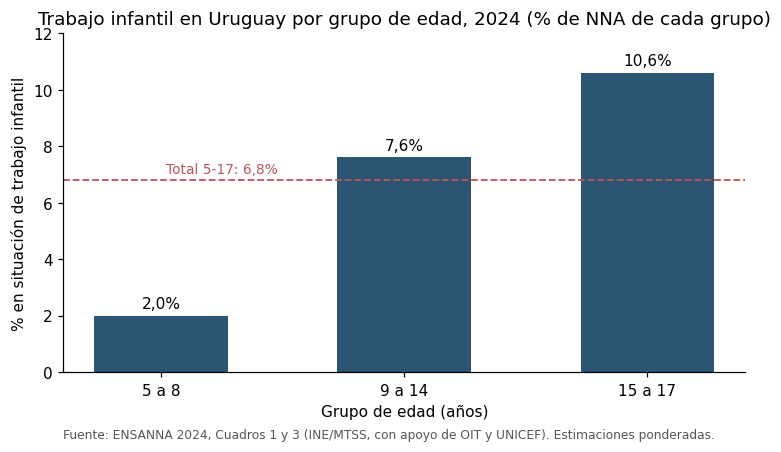

In [20]:
ed = ENS[(ENS["metrica"] == "trabajo_infantil") & (ENS["unidad"] == "porcentaje") &
         (ENS["categoria"].str.startswith("edad="))].copy()
ed["grupo"] = ed["categoria"].str.replace("edad=", "", regex=False)
total = float(ENS[(ENS["metrica"] == "trabajo_infantil") & (ENS["categoria"] == "total") &
                  (ENS["unidad"] == "porcentaje")]["valor"].iloc[0])
fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.bar(ed["grupo"], ed["valor"], color=COLOR, width=0.55)
ax.axhline(total, color=ACENTO, linewidth=1.2, linestyle="--")
ax.annotate(f"Total 5-17: {pct(total)}", (0.02, total + 0.25), fontsize=9, color=ACENTO)
ax.bar_label(barras, labels=[pct(v) for v in ed["valor"]], padding=3, fontsize=10)
ax.set_ylim(0, 12)
ax.set_title("Trabajo infantil en Uruguay por grupo de edad, 2024 (% de NNA de cada grupo)")
ax.set_ylabel("% en situación de trabajo infantil")
ax.set_xlabel("Grupo de edad (años)")
fuente(fig, "Fuente: ENSANNA 2024, Cuadros 1 y 3 (INE/MTSS, con apoyo de OIT y UNICEF). Estimaciones ponderadas.")
plt.show()

**Por qué esta gráfica.** Barras verticales para pocas categorías
ordinales en su orden natural, eje desde cero y línea de referencia del
total (Cleveland y McGill, 1984; Few; Tufte).

**Lectura**: 6,8% de los NNA de 5 a 17 años — 40.200 — está en situación
de trabajo infantil, con tasa creciente con la edad (10,6% entre 15 y
17). El gradiente se repite en las demás aperturas del boletín: interior
7,7% frente a Montevideo 5,2%, y nivel socioeconómico bajo 7,9% frente a
alto 4,8%. A diferencia de los temas 1 y 2, estas cifras sí son
prevalencia: describen a la población.

### Métrica 17. Componentes del trabajo infantil por sexo, 2024

**¿Qué pregunta responde?** ¿El trabajo infantil de niñas y varones es
del mismo tipo?

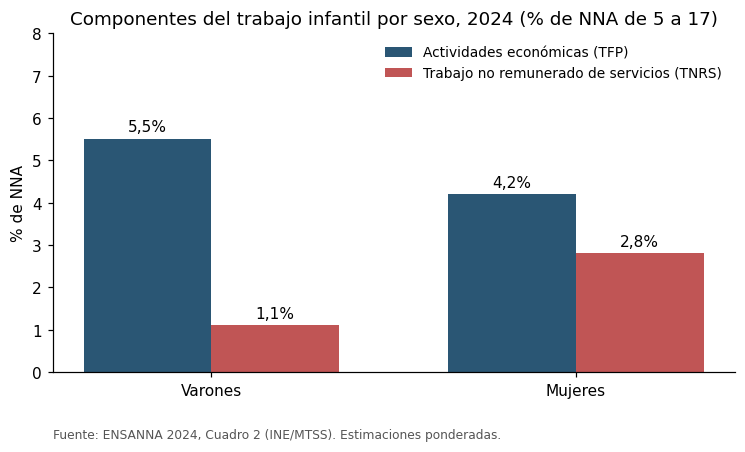

In [21]:
def valor_ens(metrica, categoria):
    f = ENS[(ENS["metrica"] == metrica) & (ENS["categoria"] == categoria) &
            (ENS["unidad"] == "porcentaje")]
    return float(f["valor"].iloc[0])

grupos = ["Varones", "Mujeres"]
tfp = [valor_ens("trabajo_frontera_produccion", "sexo=Varon"),
       valor_ens("trabajo_frontera_produccion", "sexo=Mujer")]
tnrs = [valor_ens("trabajo_no_remunerado_servicios", "sexo=Varon"),
        valor_ens("trabajo_no_remunerado_servicios", "sexo=Mujer")]
x = np.arange(2)
ancho = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
b1 = ax.bar(x - ancho / 2, tfp, ancho, color=COLOR, label="Actividades económicas (TFP)")
b2 = ax.bar(x + ancho / 2, tnrs, ancho, color=ACENTO, label="Trabajo no remunerado de servicios (TNRS)")
for b in (b1, b2):
    ax.bar_label(b, labels=[pct(v) for v in b.datavalues], padding=3, fontsize=10)
ax.set_xticks(x, grupos)
ax.set_ylim(0, 8)
ax.set_title("Componentes del trabajo infantil por sexo, 2024 (% de NNA de 5 a 17)")
ax.set_ylabel("% de NNA")
ax.legend(frameon=False, fontsize=9)
fuente(fig, "Fuente: ENSANNA 2024, Cuadro 2 (INE/MTSS). Estimaciones ponderadas.")
plt.show()

**Por qué esta gráfica.** Barras agrupadas para comparar el mismo dato
entre grupos, lado a lado (Few) — las dos componentes no se apilan
porque cada una tiene su propia definición y no suman una tasa
conjunta interpretable por adición simple.

**Lectura**: el trabajo infantil tiene sexo según su tipo. En
actividades económicas los varones superan a las mujeres (5,5% frente a
4,2%); en el trabajo no remunerado de servicios del hogar la relación se
invierte y más que duplica: 2,8% de las niñas frente a 1,1% de los
varones. La división sexual del trabajo empieza en la infancia.

### Métrica 18. Comparación puntual 2010 ↔ 2024

**¿Qué pregunta responde?** ¿Qué se puede decir — y qué no — al comparar
la medición 2024 con su antecedente de 2010?

**Advertencia de fuente**: la ENTI 2010 publicó dos definiciones (9,9%
restringida; 13,4% amplia) y su propio informe advierte problemas de
comparabilidad. No hay serie: hay dos mediciones con metodologías
distintas.

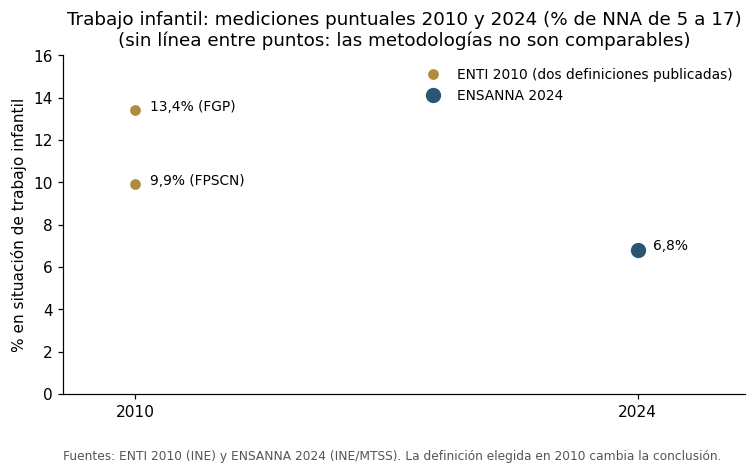

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([2010, 2010], [9.9, 13.4], marker="o", linestyle="none", color=PALETA[3],
        label="ENTI 2010 (dos definiciones publicadas)")
ax.plot([2024], [6.8], marker="o", linestyle="none", color=COLOR, markersize=9,
        label="ENSANNA 2024")
for x_p, y_p, et in [(2010, 9.9, "9,9% (FPSCN)"), (2010, 13.4, "13,4% (FGP)"), (2024, 6.8, "6,8%")]:
    ax.annotate(et, (x_p, y_p), textcoords="offset points", xytext=(10, 0), fontsize=9)
ax.set_xlim(2008, 2027)
ax.set_ylim(0, 16)
ax.set_xticks([2010, 2024])
ax.set_title(
    "Trabajo infantil: mediciones puntuales 2010 y 2024 (% de NNA de 5 a 17)\n"
    "(sin línea entre puntos: las metodologías no son comparables)"
)
ax.set_ylabel("% en situación de trabajo infantil")
ax.legend(frameon=False, fontsize=9)
fuente(fig, "Fuentes: ENTI 2010 (INE) y ENSANNA 2024 (INE/MTSS). La definición elegida en 2010 cambia la conclusión.")
plt.show()

**Por qué esta gráfica.** Puntos sueltos sin línea que los una — la
convención específica del proyecto para mediciones sin comparabilidad
verificada: una línea inventaría una tendencia que no se midió.

**Lectura**: la lectura honesta es un rango: el trabajo infantil habría
descendido desde entre 9,9% y 13,4% (2010, según la definición) hasta
6,8% (2024). La dirección de la mejora es consistente con cualquiera de
las dos definiciones; su magnitud exacta no es medible con las fuentes
disponibles.

### Métrica 19. Trabajo adolescente (14-17) — cálculo propio sobre la ECH

**¿Qué pregunta responde?** ¿Qué proporción de adolescentes de 14 a 17
años está ocupada, y en qué condiciones?

**Precisión de alcance**: el módulo de empleo de la ECH comienza a los
14 años — esta métrica cubre trabajo adolescente, no el trabajo
infantil de 5-13 (que solo mide la ENSANNA).

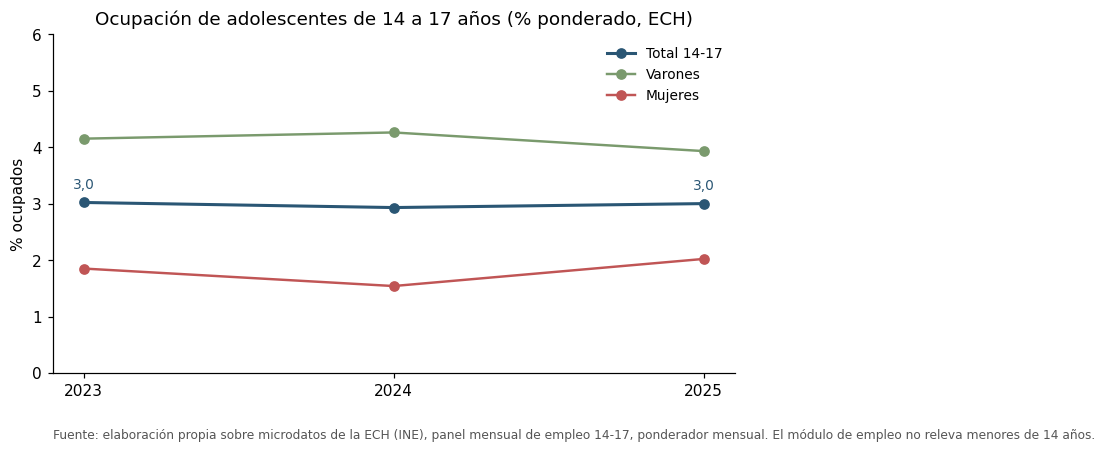

In [23]:
ta = ECHM[ECHM["metrica"] == "trabajo_adolescente_14a17"]
tot = ta[ta["categoria"] == "ocupacion=total"].sort_values("anio")
var = ta[ta["categoria"] == "ocupacion=sexo:Varones"].sort_values("anio")
muj = ta[ta["categoria"] == "ocupacion=sexo:Mujeres"].sort_values("anio")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tot["anio"], tot["valor"], marker="o", color=COLOR, linewidth=2, label="Total 14-17")
ax.plot(var["anio"], var["valor"], marker="o", color=PALETA[2], linewidth=1.6, label="Varones")
ax.plot(muj["anio"], muj["valor"], marker="o", color=ACENTO, linewidth=1.6, label="Mujeres")
ax.set_ylim(0, 6)
ax.set_xticks(tot["anio"])
ax.set_title("Ocupación de adolescentes de 14 a 17 años (% ponderado, ECH)")
ax.set_ylabel("% ocupados")
ax.legend(frameon=False, fontsize=9)
anotar_extremos(ax, tot["anio"].to_numpy(), tot["valor"].to_numpy(), COLOR, dec=1)
fuente(fig, "Fuente: elaboración propia sobre microdatos de la ECH (INE), panel mensual de empleo 14-17, "
            "ponderador mensual. El módulo de empleo no releva menores de 14 años.")
plt.show()

**Por qué esta gráfica.** Tres líneas (total y por sexo) sobre una serie
corta de cálculo propio ponderado; eje desde cero.

**Lectura**: alrededor del 3% de los adolescentes de 14 a 17 está
ocupado (3,0% en 2025), con los varones duplicando o cuadruplicando a
las mujeres según el año. El dato más relevante está en la condición: la
informalidad entre los adolescentes ocupados es masiva (82-93% según el
año, frente a ~20% en el conjunto de los ocupados del país) — el trabajo
adolescente que existe ocurre casi todo fuera de la protección de la
seguridad social.

## Tema 4 — Protección especial (INAU)

Indicadores del Sistema de Protección Especial (SPE) del INAU, con
fuente en el SIPI (Sistema de Información Para la Infancia). Describen a
la **población atendida por el INAU** — los NNA que están en el sistema
de protección — no a la infancia uruguaya en general. Serie anual
2020-2025 a nivel nacional; los mismos indicadores existen por
departamento con frecuencia semestral.

Términos utilizados por la fuente:

- **Cuidado residencial / contexto familiar**: las dos grandes
  modalidades de cuidado; reducir la primera en favor de la segunda
  («desinternación») es el eje declarado de la política.
- **SPE**: incluye también a jóvenes de 18 años y más que permanecen en
  proyectos del sistema; cuando una métrica se restringe a 0-17, se
  indica.

### Métrica 20. NNA atendidos en el Sistema de Protección Especial

**¿Qué pregunta responde?** ¿Cuántas personas atiende el sistema de
protección especial y qué proporción de la población del país
representa?

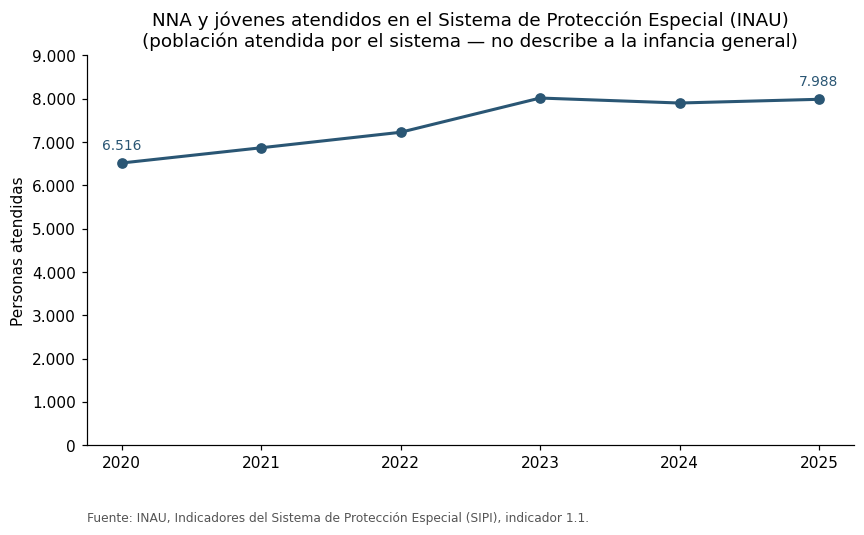

In [24]:
anios_i, atendidos = serie_inau("1.1")
fig, ax = plt.subplots()
ax.plot(anios_i, atendidos, marker="o", color=COLOR, linewidth=2)
ax.set_ylim(0, 9000)
ax.set_xticks(anios_i)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt(v)))
ax.set_title(
    "NNA y jóvenes atendidos en el Sistema de Protección Especial (INAU)\n"
    "(población atendida por el sistema — no describe a la infancia general)"
)
ax.set_ylabel("Personas atendidas")
anotar_extremos(ax, anios_i, atendidos, COLOR)
fuente(fig, "Fuente: INAU, Indicadores del Sistema de Protección Especial (SIPI), indicador 1.1.")
plt.show()

**Por qué esta gráfica.** Serie anual de conteos: línea con marcadores,
eje desde cero, extremos anotados.

**Lectura**: el sistema pasó de 6.516 personas atendidas en 2020 a 7.988
en 2025, con el máximo en 2023 (8.017) y estabilización posterior.
Restringido a 0-17 años (sumando los tramos de edad del indicador), la
población atendida pasó de 5.583 a 7.043 y también se amesetó desde
2023. Como proporción de la población total del país, el sistema
atiende cerca del 1% (0,77% en 2020 → 0,97% en 2025, indicador 1.3).

### Métrica 21. Cuidado residencial frente a contexto familiar

**¿Qué pregunta responde?** ¿Avanza la desinternación — que los NNA del
sistema vivan en contexto familiar y no en residencias?

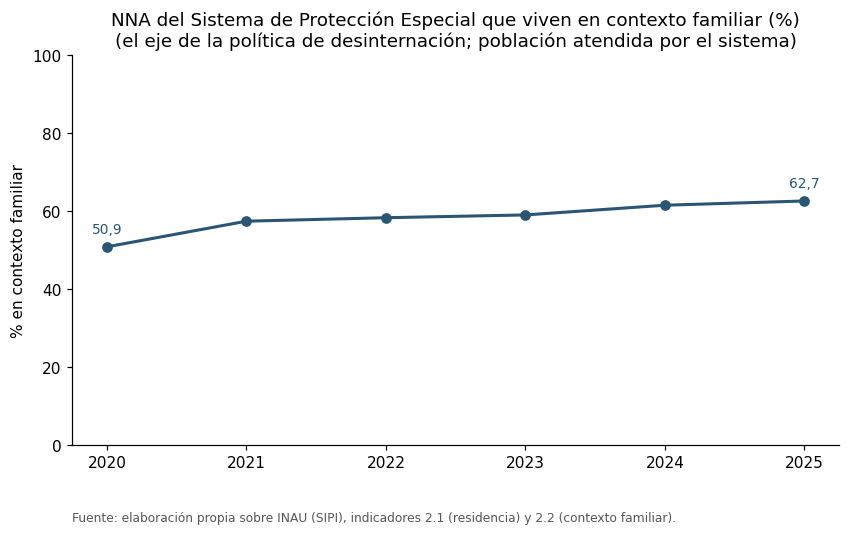

In [25]:
anios_r, resid = serie_inau("2.1")
_, familia = serie_inau("2.2")
pct_familia = familia / (resid + familia) * 100
fig, ax = plt.subplots()
ax.plot(anios_r, pct_familia, marker="o", color=COLOR, linewidth=2)
ax.set_ylim(0, 100)
ax.set_xticks(anios_r)
ax.set_title(
    "NNA del Sistema de Protección Especial que viven en contexto familiar (%)\n"
    "(el eje de la política de desinternación; población atendida por el sistema)"
)
ax.set_ylabel("% en contexto familiar")
anotar_extremos(ax, anios_r, pct_familia, COLOR, dec=1)
fuente(fig, "Fuente: elaboración propia sobre INAU (SIPI), indicadores 2.1 (residencia) y 2.2 (contexto familiar).")
plt.show()

**Por qué esta gráfica.** La proporción en contexto familiar resume en
una sola serie la relación entre las dos modalidades; eje 0-100 completo
para no exagerar el avance (Healy, 2018).

**Lectura**: la desinternación avanza de forma sostenida: 50,9% de los
NNA del sistema vivía en contexto familiar en 2020 y 62,7% en 2025. En
términos del ratio que publica la fuente, se pasó de prácticamente un
NNA en residencia por cada uno en familia (0,97) a 0,6. El avance es
consistente pero se desacelera en los últimos semestres — la proyección
P3 estima su trayectoria.

### Métrica 22. Ingresos al sistema: primera vez y reingresos

**¿Qué pregunta responde?** ¿Cuánto de la demanda del sistema es nueva y
cuánta es reincidencia de trayectorias anteriores?

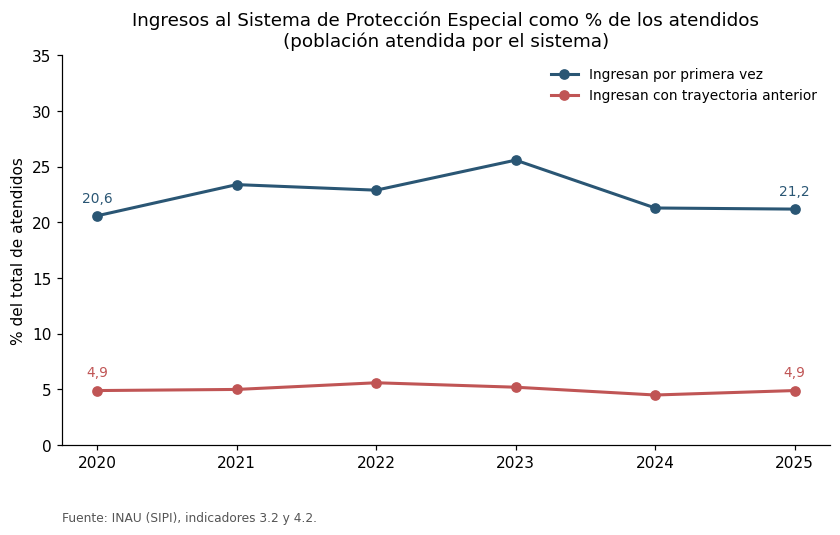

In [26]:
anios_p, primera = serie_inau("3.2")
_, reingreso = serie_inau("4.2")
fig, ax = plt.subplots()
ax.plot(anios_p, primera, marker="o", color=COLOR, linewidth=2, label="Ingresan por primera vez")
ax.plot(anios_p, reingreso, marker="o", color=ACENTO, linewidth=2, label="Ingresan con trayectoria anterior")
ax.set_ylim(0, 35)
ax.set_xticks(anios_p)
ax.set_title(
    "Ingresos al Sistema de Protección Especial como % de los atendidos\n"
    "(población atendida por el sistema)"
)
ax.set_ylabel("% del total de atendidos")
ax.legend(frameon=False, fontsize=9)
anotar_extremos(ax, anios_p, primera, COLOR, dec=1)
anotar_extremos(ax, anios_p, reingreso, ACENTO, dec=1)
fuente(fig, "Fuente: INAU (SIPI), indicadores 3.2 y 4.2.")
plt.show()

**Por qué esta gráfica.** Dos líneas en el mismo plano porque comparten
unidad y denominador (% del total de atendidos); no se apilan porque no
agotan el universo.

**Lectura**: cada año, entre 21% y 26% de los atendidos son ingresos por
primera vez, mientras que los reingresos con trayectoria anterior se
mantienen en torno al 5%. La demanda nueva domina sobre la reincidencia
— la puerta de entrada del sistema sigue muy activa, coherente con el
crecimiento de la métrica 20 hasta 2023.

### Métrica 23. Egresos del sistema

**¿Qué pregunta responde?** ¿A qué ritmo egresan los NNA del sistema de
protección?

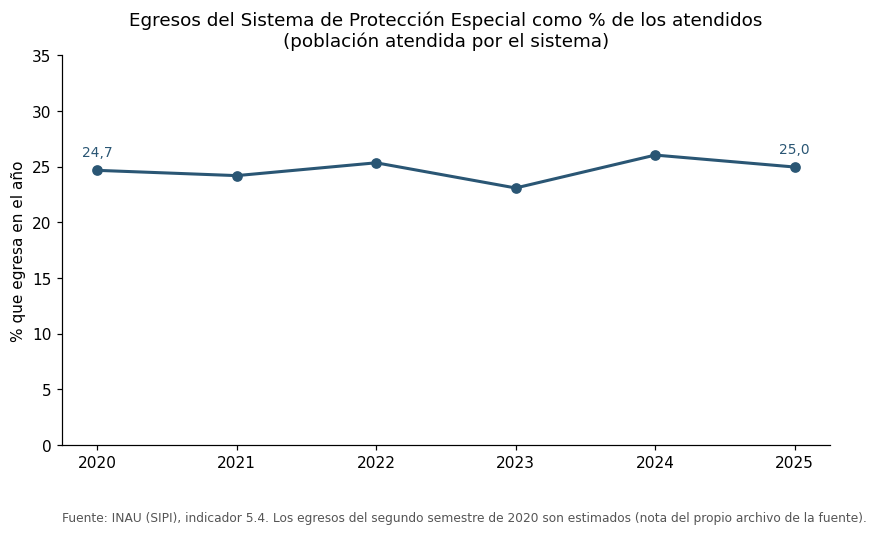

In [27]:
anios_e, egresos = serie_inau("5.4")
fig, ax = plt.subplots()
ax.plot(anios_e, egresos, marker="o", color=COLOR, linewidth=2)
ax.set_ylim(0, 35)
ax.set_xticks(anios_e)
ax.set_title(
    "Egresos del Sistema de Protección Especial como % de los atendidos\n"
    "(población atendida por el sistema)"
)
ax.set_ylabel("% que egresa en el año")
anotar_extremos(ax, anios_e, egresos, COLOR, dec=1)
fuente(fig, "Fuente: INAU (SIPI), indicador 5.4. Los egresos del segundo semestre de 2020 son estimados "
            "(nota del propio archivo de la fuente).")
plt.show()

**Por qué esta gráfica.** Serie anual simple: línea con marcadores, eje
desde cero.

**Lectura**: el sistema egresa cada año a alrededor de un cuarto de su
población atendida (23-26%). Combinado con la métrica 22 (más ingresos
que egresos hasta 2023), el saldo explica el crecimiento del stock. Los
tiempos de permanencia — publicados desde 2021 — completan esta lectura
en la fuente.

### Métrica 24. Tránsito de residencia a familia

**¿Qué pregunta responde?** ¿Cuántos NNA dejan el cuidado residencial
para pasar a vivir con una familia?

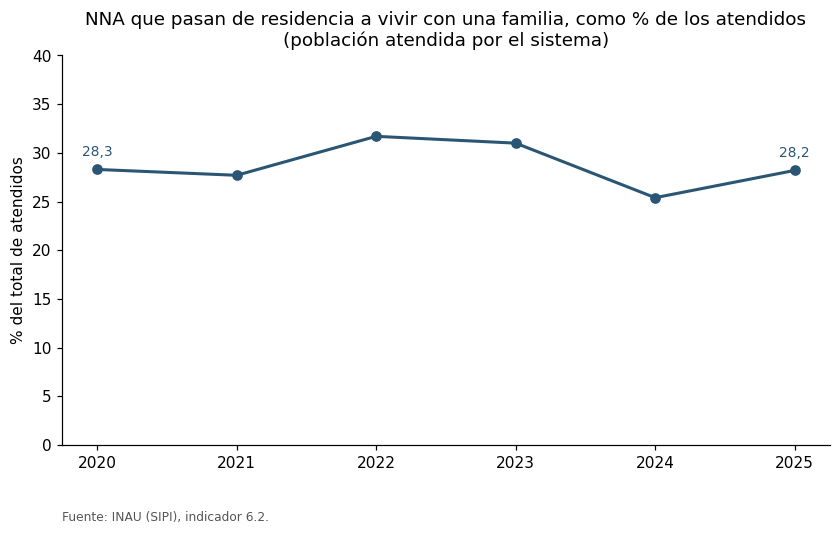

In [28]:
anios_t, transito = serie_inau("6.2")
fig, ax = plt.subplots()
ax.plot(anios_t, transito, marker="o", color=COLOR, linewidth=2)
ax.set_ylim(0, 40)
ax.set_xticks(anios_t)
ax.set_title(
    "NNA que pasan de residencia a vivir con una familia, como % de los atendidos\n"
    "(población atendida por el sistema)"
)
ax.set_ylabel("% del total de atendidos")
anotar_extremos(ax, anios_t, transito, COLOR, dec=1)
fuente(fig, "Fuente: INAU (SIPI), indicador 6.2.")
plt.show()

**Por qué esta gráfica.** Serie anual simple, misma convención que las
anteriores del tema.

**Lectura**: entre 25% y 32% de los atendidos pasa cada año de
residencia a un entorno familiar (28,2% en 2025, con máximo de 31,7% en
2022). Es el flujo que sostiene el avance de la desinternación que
muestra la métrica 21.

### Métrica 25. Adopciones: condición de adoptabilidad y tenencia

**¿Qué pregunta responde?** ¿Cuántos NNA del sistema tienen condición de
adoptabilidad declarada, y cuántos avanzan a tenencia?

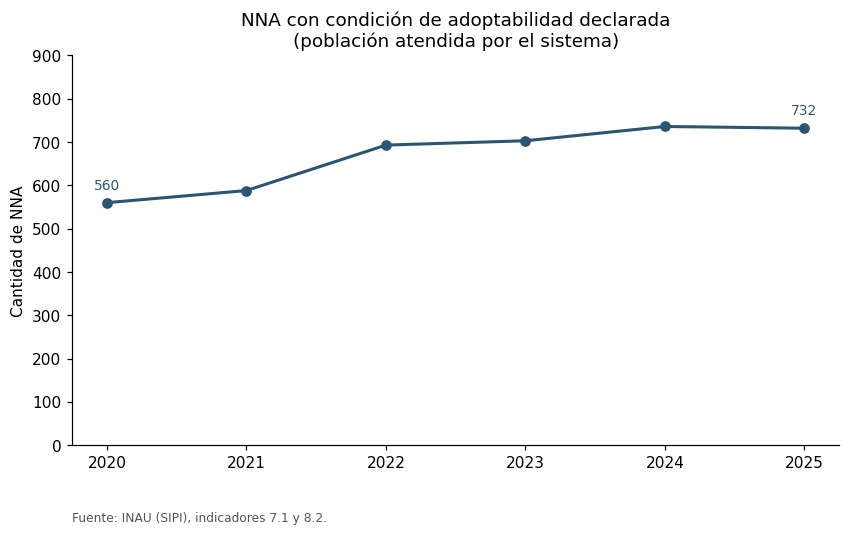

In [29]:
anios_a, adoptables = serie_inau("7.1")
fig, ax = plt.subplots()
ax.plot(anios_a, adoptables, marker="o", color=COLOR, linewidth=2)
ax.set_ylim(0, 900)
ax.set_xticks(anios_a)
ax.set_title(
    "NNA con condición de adoptabilidad declarada\n"
    "(población atendida por el sistema)"
)
ax.set_ylabel("Cantidad de NNA")
anotar_extremos(ax, anios_a, adoptables, COLOR)
fuente(fig, "Fuente: INAU (SIPI), indicadores 7.1 y 8.2.")
plt.show()

**Por qué esta gráfica.** Serie anual de un conteo; el segundo indicador
del proceso (paso a tenencia) se reporta en la lectura para no
superponer unidades distintas (cantidad y porcentaje) en un mismo eje.

**Lectura**: los NNA con condición de adoptabilidad pasaron de 560
(2020) a 732 (2025), alrededor del 7-8% de los atendidos. De ellos, solo
entre 15% y 18% pasa cada año a seguimiento de tenencia (15,4% en
2025): la distancia entre adoptabilidad declarada y adopción efectiva es
el cuello de botella que la fuente permite dimensionar.

### Métrica 26. Frecuencia de contacto con la familia o referentes

**¿Qué pregunta responde?** ¿Con qué frecuencia los NNA atendidos
mantienen contacto con sus familias o referentes afectivos?

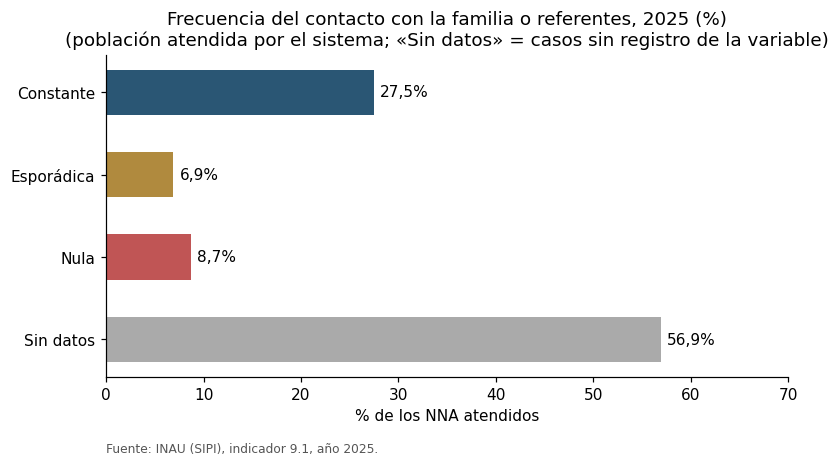

In [30]:
n91 = INAU[(INAU["indicador_codigo"] == "9.1") & (INAU["anio"] == 2025) &
           (INAU["apertura"].str.match(r"^frecuencia="))].copy()
n91["cat"] = n91["apertura"].str.replace("frecuencia=", "", regex=False)
orden = ["Constante", "Esporádica", "Nula", "Sin datos"]
n91 = n91.set_index("cat").loc[orden]
colores = [COLOR, PALETA[3], ACENTO, "#aaaaaa"]
fig, ax = plt.subplots(figsize=(8, 3.8))
barras = ax.barh(orden[::-1], n91["valor"].to_numpy()[::-1], color=colores[::-1], height=0.55)
ax.bar_label(barras, labels=[pct(v) for v in barras.datavalues], padding=4, fontsize=10)
ax.set_xlim(0, 70)
ax.set_title(
    "Frecuencia del contacto con la familia o referentes, 2025 (%)\n"
    "(población atendida por el sistema; «Sin datos» = casos sin registro de la variable)"
)
ax.set_xlabel("% de los NNA atendidos")
fuente(fig, "Fuente: INAU (SIPI), indicador 9.1, año 2025.", y=-0.07)
plt.show()

**Por qué esta gráfica.** Barras horizontales para categorías con
nombre, **incluida la categoría de datos faltantes**: ocultar el «sin
datos» haría parecer que el 27,5% con contacto constante es mayoría,
cuando la mayoría real es la falta de registro.

**Lectura**: entre quienes tienen la variable registrada, el contacto
constante domina (27,5% del total) sobre el esporádico (6,9%) y el nulo
(8,7%). Pero el dato principal es otro: **56,9% de los casos no tiene
registro de esta variable** — la calidad del registro es hoy el límite
de lo que esta métrica puede decir, y así se reporta.

### Métrica 27. Educación de los NNA del sistema

**¿Qué pregunta responde?** ¿Los NNA atendidos por el sistema asisten a
la educación?

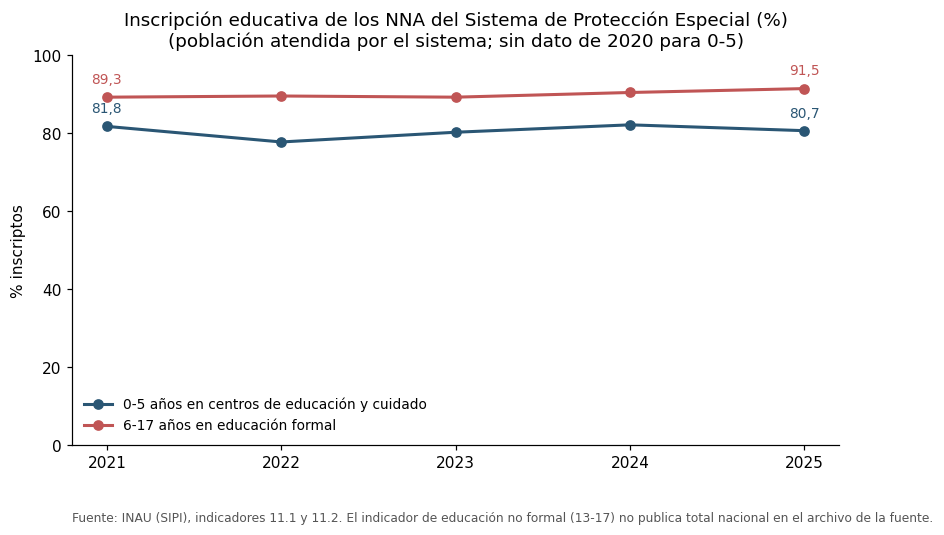

In [31]:
anios_11, ed05 = serie_inau("11.1")
anios_12, ed617 = serie_inau("11.2")
fig, ax = plt.subplots()
ax.plot(anios_11, ed05, marker="o", color=COLOR, linewidth=2,
        label="0-5 años en centros de educación y cuidado")
ax.plot(anios_12, ed617, marker="o", color=ACENTO, linewidth=2,
        label="6-17 años en educación formal")
ax.set_ylim(0, 100)
ax.set_xticks(anios_12)
ax.set_title(
    "Inscripción educativa de los NNA del Sistema de Protección Especial (%)\n"
    "(población atendida por el sistema; sin dato de 2020 para 0-5)"
)
ax.set_ylabel("% inscriptos")
ax.legend(frameon=False, fontsize=9)
anotar_extremos(ax, anios_11, ed05, COLOR, dec=1)
anotar_extremos(ax, anios_12, ed617, ACENTO, dec=1)
fuente(fig, "Fuente: INAU (SIPI), indicadores 11.1 y 11.2. El indicador de educación no formal (13-17) "
            "no publica total nacional en el archivo de la fuente.")
plt.show()

**Por qué esta gráfica.** Dos líneas con la misma unidad y universos
declarados por tramo; eje 0-100.

**Lectura**: la inscripción en educación formal de los 6-17 es alta y
creciente (89,3% en 2021 → 91,5% en 2025); la de 0-5 en centros de
educación y cuidado ronda el 78-82%. La contracara: aun dentro del
sistema de protección, cerca de 1 de cada 10 NNA de 6 a 17 no está
inscripto en educación formal.

### Métrica 28. Salud: controles y vacunas al día

**¿Qué pregunta responde?** ¿Los NNA atendidos tienen su atención básica
de salud al día?

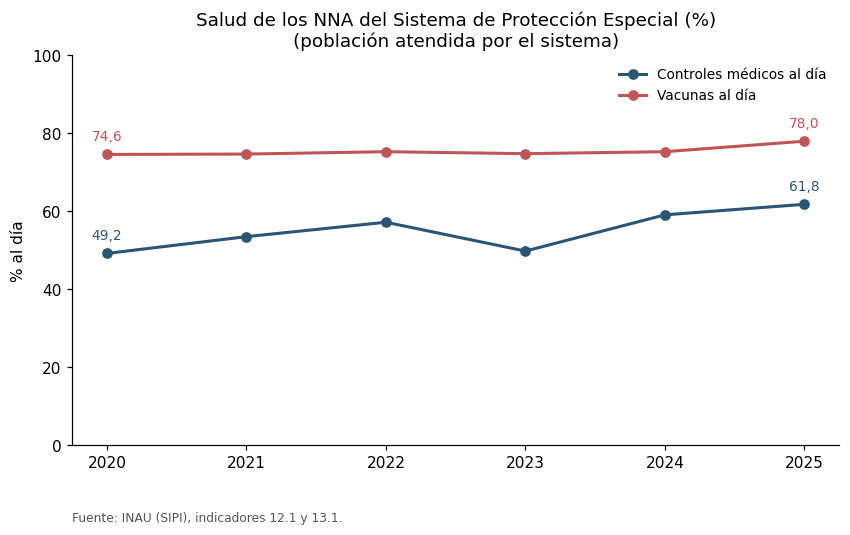

In [32]:
anios_s, controles = serie_inau("12.1")
_, vacunas = serie_inau("13.1")
fig, ax = plt.subplots()
ax.plot(anios_s, controles, marker="o", color=COLOR, linewidth=2, label="Controles médicos al día")
ax.plot(anios_s, vacunas, marker="o", color=ACENTO, linewidth=2, label="Vacunas al día")
ax.set_ylim(0, 100)
ax.set_xticks(anios_s)
ax.set_title(
    "Salud de los NNA del Sistema de Protección Especial (%)\n"
    "(población atendida por el sistema)"
)
ax.set_ylabel("% al día")
ax.legend(frameon=False, fontsize=9)
anotar_extremos(ax, anios_s, controles, COLOR, dec=1)
anotar_extremos(ax, anios_s, vacunas, ACENTO, dec=1)
fuente(fig, "Fuente: INAU (SIPI), indicadores 12.1 y 13.1.")
plt.show()

**Por qué esta gráfica.** Dos líneas de la misma unidad; eje 0-100
completo para que la distancia al 100% — que es el dato — sea visible.

**Lectura**: ambos indicadores mejoran (controles: 49,2% en 2020 → 61,8%
en 2025; vacunas: 74,6% → 78,0%), pero el nivel sigue siendo el
hallazgo: en una población bajo cuidado del Estado, casi 4 de cada 10
NNA no tienen los controles médicos al día y más de 2 de cada 10 no
tienen las vacunas al día.

### Métrica 29. Acogimiento familiar por tipo de familia (abril 2025)

**¿Qué pregunta responde?** ¿En qué tipo de familias se acogen los NNA
que no viven con su familia de origen?

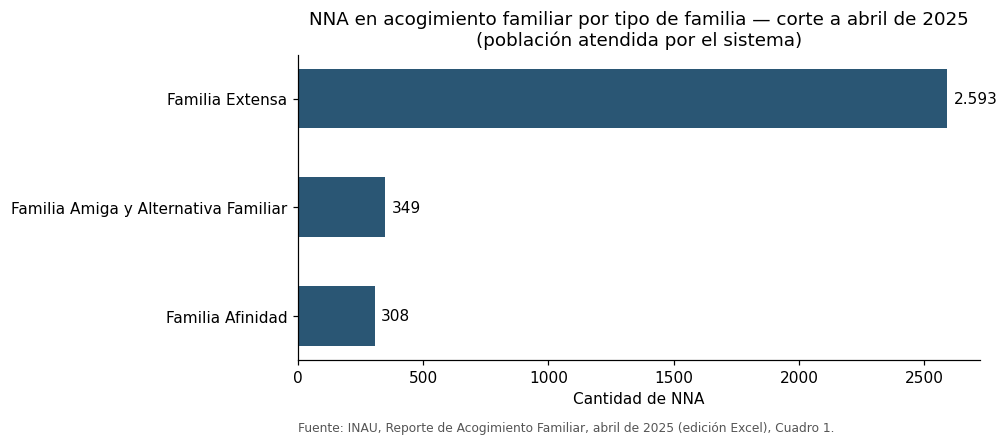

In [33]:
raf = RAF[(RAF["cuadro"] == "Cuadro 1") & (RAF["departamento"] == "Total país") &
          (RAF["columna"] == "Total general") &
          (RAF["fila"].isin(["Familia Amiga y Alternativa Familiar", "Familia Extensa", "Familia Afinidad"]))]
raf = raf.sort_values("valor")
fig, ax = plt.subplots(figsize=(8, 3.6))
barras = ax.barh(raf["fila"], raf["valor"], color=COLOR, height=0.55)
ax.bar_label(barras, labels=[fmt(v) for v in barras.datavalues], padding=4, fontsize=10)
ax.set_title(
    "NNA en acogimiento familiar por tipo de familia — corte a abril de 2025\n"
    "(población atendida por el sistema)"
)
ax.set_xlabel("Cantidad de NNA")
fuente(fig, "Fuente: INAU, Reporte de Acogimiento Familiar, abril de 2025 (edición Excel), Cuadro 1.", y=-0.07)
plt.show()

**Por qué esta gráfica.** Barras horizontales ordenadas por magnitud
para categorías con nombres largos (Cleveland y McGill, 1984; orden por
total, Ware).

**Lectura**: el acogimiento se apoya sobre todo en la red del propio
NNA: la familia extensa y la familia por afinidad concentran la mayor
parte de los acogimientos, mientras el programa de familias amigas y
alternativas familiares — captación de familias sin vínculo previo —
aporta el grupo menor. La fuente permite además la apertura por etapa de
desarrollo, sexo y departamento.

### Métrica 30. Dónde viven los NNA acompañados por el sistema (abril 2025)

**¿Qué pregunta responde?** Considerando a todos los NNA vinculados a
dispositivos de protección, ¿dónde están viviendo?

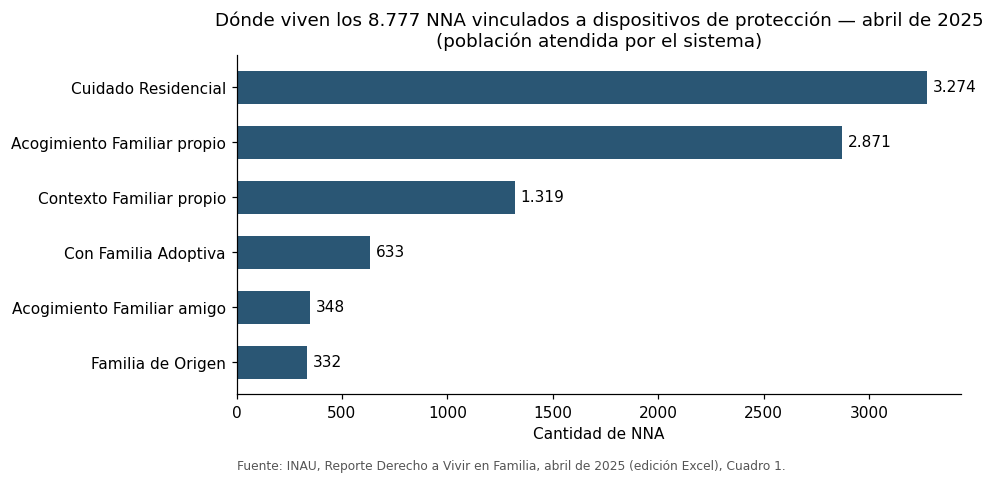

In [34]:
dvf = DVF[(DVF["cuadro"] == "Cuadro 1") & (DVF["departamento"] == "Total país") &
          (DVF["fila"] == "Total") & (DVF["columna"] != "total")].copy()
dvf["lugar"] = (dvf["columna"].str.replace(r"\d+$", "", regex=True).str.strip())
dvf = dvf.sort_values("valor")
total_dvf = dvf["valor"].sum()
fig, ax = plt.subplots(figsize=(8.5, 4))
barras = ax.barh(dvf["lugar"], dvf["valor"], color=COLOR, height=0.6)
ax.bar_label(barras, labels=[fmt(v) for v in barras.datavalues], padding=4, fontsize=10)
ax.set_title(
    f"Dónde viven los {fmt(total_dvf)} NNA vinculados a dispositivos de protección — abril de 2025\n"
    "(población atendida por el sistema)"
)
ax.set_xlabel("Cantidad de NNA")
fuente(fig, "Fuente: INAU, Reporte Derecho a Vivir en Familia, abril de 2025 (edición Excel), Cuadro 1.", y=-0.06)
plt.show()

**Por qué esta gráfica.** Barras horizontales ordenadas por magnitud —
misma convención que la métrica 29, con el total en el título para dar
el denominador de una sola vez.

**Lectura**: la fotografía de abril de 2025 muestra la composición
residencial completa de los NNA acompañados: el cuidado residencial
sigue siendo el destino de una parte sustantiva, pero la mayoría vive en
entornos familiares (familia de origen, contexto familiar propio,
acogimientos y familias adoptivas). Es el corte transversal que
complementa la serie de la métrica 21.

### Proyección P3. Desinternación proyectada por departamento, 2026-2027

**¿Qué pregunta responde?** Si el ritmo de desinternación persiste, ¿qué
proporción de los NNA del sistema vivirá en contexto familiar hacia
fines de 2027, y en qué departamentos?

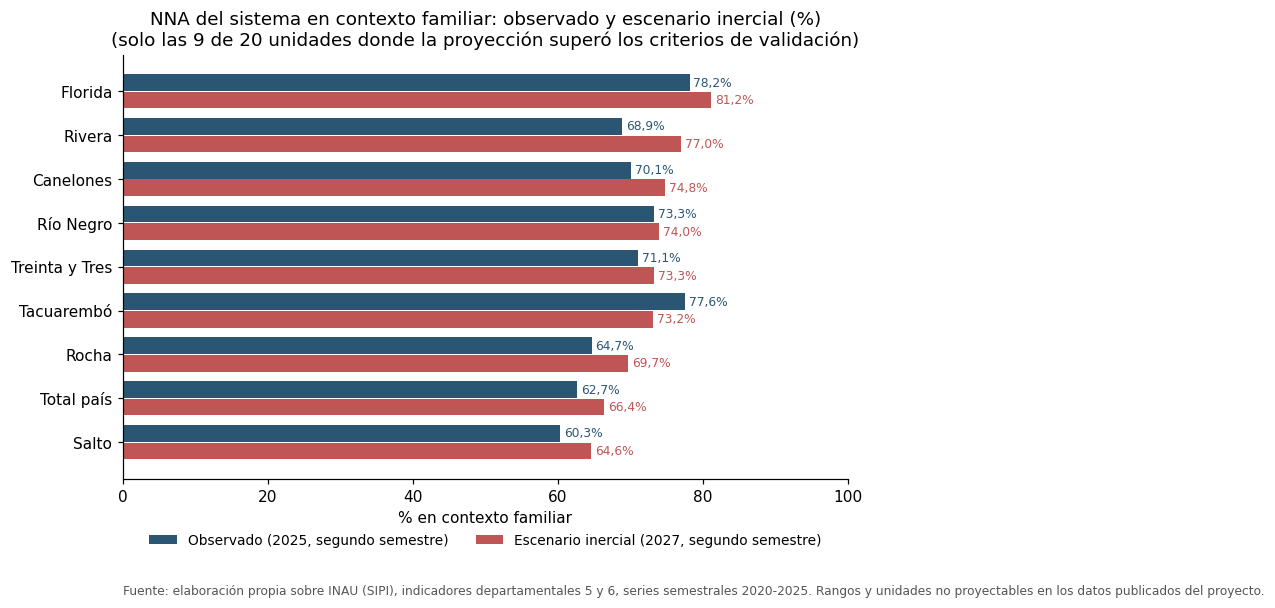

In [35]:
p3 = P3[P3["modelo"] != "no_proyectable"].sort_values("proy_2027-S2")
fig, ax = plt.subplots(figsize=(8.5, 5))
y_pos = np.arange(len(p3))
ax.barh(y_pos + 0.2, p3["ultimo_observado_2025S2"], height=0.38, color=COLOR,
        label="Observado (2025, segundo semestre)")
ax.barh(y_pos - 0.2, p3["proy_2027-S2"], height=0.38, color=ACENTO,
        label="Escenario inercial (2027, segundo semestre)")
ax.set_yticks(y_pos, p3["unidad_territorial"])
for i, (obs, proy) in enumerate(zip(p3["ultimo_observado_2025S2"], p3["proy_2027-S2"])):
    ax.annotate(pct(obs), (obs + 0.5, i + 0.2), fontsize=8, va="center", color=COLOR)
    ax.annotate(pct(proy), (proy + 0.5, i - 0.2), fontsize=8, va="center", color=ACENTO)
ax.set_xlim(0, 100)
ax.set_title(
    "NNA del sistema en contexto familiar: observado y escenario inercial (%)\n"
    "(solo las 9 de 20 unidades donde la proyección superó los criterios de validación)"
)
ax.set_xlabel("% en contexto familiar")
ax.legend(frameon=False, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=2)
fuente(fig, "Fuente: elaboración propia sobre INAU (SIPI), indicadores departamentales 5 y 6, series semestrales "
            "2020-2025. Rangos y unidades no proyectables en los datos publicados del proyecto.", y=-0.10)
plt.show()

**Por qué esta gráfica.** Barras agrupadas observado/proyectado por
unidad territorial, mostrando **solo** las unidades cuyo modelo superó
el backtest — las 11 restantes no se fuerzan: las estables se reportan
como «se mantiene» y las erráticas como no proyectables (protocolo del
bloque predictivo).

**Lectura**: si el ritmo actual persiste, el total del país pasaría de
62,7% a 66,4% de los NNA del sistema en contexto familiar hacia fines de
2027 (rango 63,9-68,8). Canelones es el caso más firme (70,1% → 74,8%).
Montevideo — no graficado — es un caso distinto: su serie es tan estable
en torno a 53% que el escenario inercial es «se mantiene», sin
necesidad de modelo.

### Proyección P4. NNA en protección especial cada 1.000 NNA

**¿Qué pregunta responde?** ¿Qué proporción de la infancia uruguaya está
en el sistema de protección especial, y hacia dónde va esa tasa?

**Término** — **tasa cada 1.000 NNA**: NNA de 0 a 17 en el SPE dividido
por la población de 0 a 17 del país (proyecciones oficiales del INE,
revisión 2025), por mil.

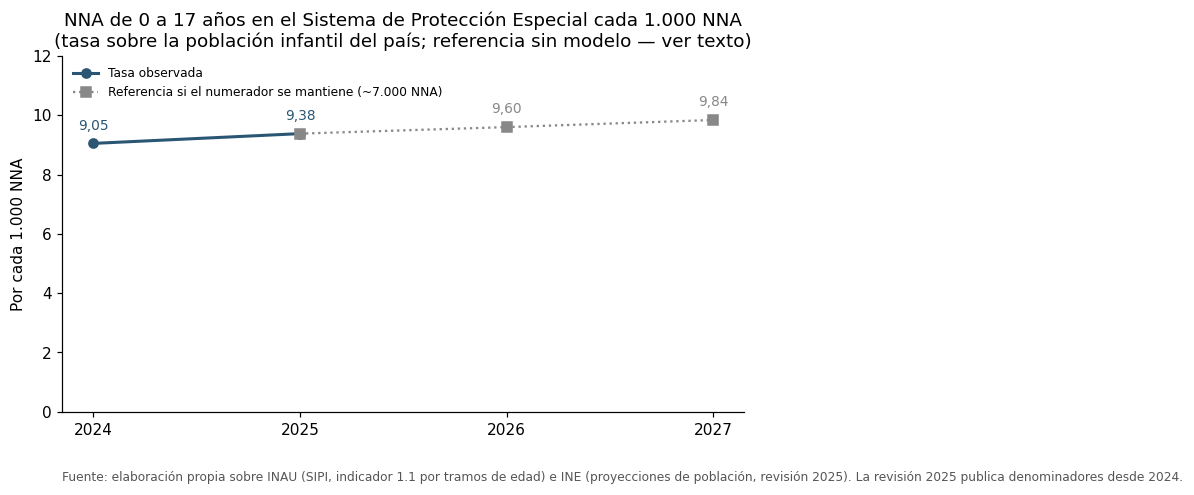

In [36]:
obs = P4[P4["tipo"] == "observado"]
ref = P4[P4["tipo"] != "observado"]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(obs["anio"], obs["tasa_por_mil"], marker="o", color=COLOR, linewidth=2,
        label="Tasa observada")
ax.plot(np.append(obs["anio"].iloc[-1], ref["anio"]),
        np.append(obs["tasa_por_mil"].iloc[-1], ref["tasa_por_mil"]),
        marker="s", linestyle=":", color="#888888",
        label="Referencia si el numerador se mantiene (~7.000 NNA)")
for _, fila in pd.concat([obs, ref]).iterrows():
    ax.annotate(f"{fila['tasa_por_mil']:.2f}".replace(".", ","), (fila["anio"], fila["tasa_por_mil"]),
                textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9,
                color=COLOR if fila["tipo"] == "observado" else "#888888")
ax.set_ylim(0, 12)
ax.set_xticks(P4["anio"])
ax.set_title(
    "NNA de 0 a 17 años en el Sistema de Protección Especial cada 1.000 NNA\n"
    "(tasa sobre la población infantil del país; referencia sin modelo — ver texto)"
)
ax.set_ylabel("Por cada 1.000 NNA")
ax.legend(frameon=False, fontsize=8)
fuente(fig, "Fuente: elaboración propia sobre INAU (SIPI, indicador 1.1 por tramos de edad) e INE "
            "(proyecciones de población, revisión 2025). La revisión 2025 publica denominadores desde 2024.")
plt.show()

**Por qué esta gráfica.** La referencia 2026-2027 se dibuja punteada,
gris y sin banda: **no es una proyección de modelo**. El protocolo del
bloque predictivo exigía que algún modelo del numerador superara al
ingenuo en el backtest, y ninguno lo hizo (el numerador se amesetó en
torno a 7.000 desde 2023) — en ese caso no se publica proyección y el
escenario inercial se degrada a lectura descriptiva.

**Lectura**: 9,05 de cada 1.000 NNA del país estaban en el sistema de
protección especial en 2024, y 9,38 en 2025. El hallazgo está en la
descomposición: la tasa sube **aunque la cantidad de NNA atendidos ya no
crece**, porque la población infantil del país cae 2,3% por año. Si el
sistema simplemente mantiene su tamaño actual, la tasa llegará a ~9,8
por mil en 2027 solo por efecto demográfico — una advertencia general
para todas las tasas de infancia del país.

## Tema 5 — Pobreza, vivienda y entorno del hogar (ECH)

Cálculo propio sobre los **microdatos de la ECH** (INE), universo 0-17
años, siempre ponderado (2019, 2023, 2024 y 2025), con procedimientos
de carga verificados contra los diccionarios oficiales del INE.
A diferencia de los temas 1, 2 y 4, estas métricas sí describen a la
infancia uruguaya en general.

### Métrica 31. Pobreza monetaria en la infancia

**¿Qué pregunta responde?** ¿Qué proporción de NNA vive en hogares en
situación de pobreza?

**Advertencia de fuente**: la serie tiene un corte metodológico — 2019 y
2023 se calculan con la canasta 2006 del INE y 2024-2025 con la canasta
2017 (verificado contra los archivos: cada año trae solo su variable).
Los dos regímenes no se unen.

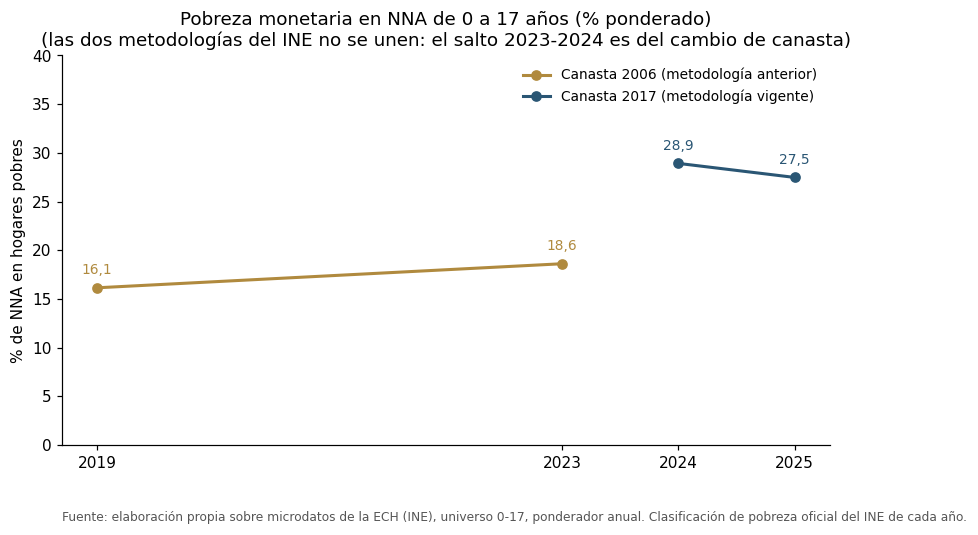

In [37]:
pob = ECHM[(ECHM["metrica"] == "pobreza_0a17") & (ECHM["categoria"] == "total")].sort_values("anio")
r1 = pob[pob["anio"] <= 2023]
r2 = pob[pob["anio"] >= 2024]
fig, ax = plt.subplots()
ax.plot(r1["anio"], r1["valor"], marker="o", color=PALETA[3], linewidth=2,
        label="Canasta 2006 (metodología anterior)")
ax.plot(r2["anio"], r2["valor"], marker="o", color=COLOR, linewidth=2,
        label="Canasta 2017 (metodología vigente)")
for df_r, c in [(r1, PALETA[3]), (r2, COLOR)]:
    anotar_extremos(ax, df_r["anio"].to_numpy(), df_r["valor"].to_numpy(), c, dec=1)
ax.set_ylim(0, 40)
ax.set_xticks(pob["anio"])
ax.set_title(
    "Pobreza monetaria en NNA de 0 a 17 años (% ponderado)\n"
    "(las dos metodologías del INE no se unen: el salto 2023-2024 es del cambio de canasta)"
)
ax.set_ylabel("% de NNA en hogares pobres")
ax.legend(frameon=False, fontsize=9)
fuente(fig, "Fuente: elaboración propia sobre microdatos de la ECH (INE), universo 0-17, ponderador anual. "
            "Clasificación de pobreza oficial del INE de cada año.")
plt.show()

**Por qué esta gráfica.** Dos segmentos con colores distintos y sin
línea entre 2023 y 2024: unir los regímenes inventaría un salto de 10
puntos que es metodológico, no social (convención de cortes de serie).

**Lectura**: con la metodología vigente, 28,9% de los NNA vivía en
hogares pobres en 2024 y 27,5% en 2025. El patrón por edad es regresivo
con la primera infancia (32,2% entre 0 y 5 años frente a 27,5% entre 13
y 17, en 2024) y la comparación con la población general (~17%)
confirma la lectura central del proyecto: la pobreza uruguaya está
concentrada en la infancia.

### Métrica 32. Hacinamiento en hogares con NNA

**¿Qué pregunta responde?** ¿Qué proporción de los hogares donde viven
NNA está en situación de hacinamiento?

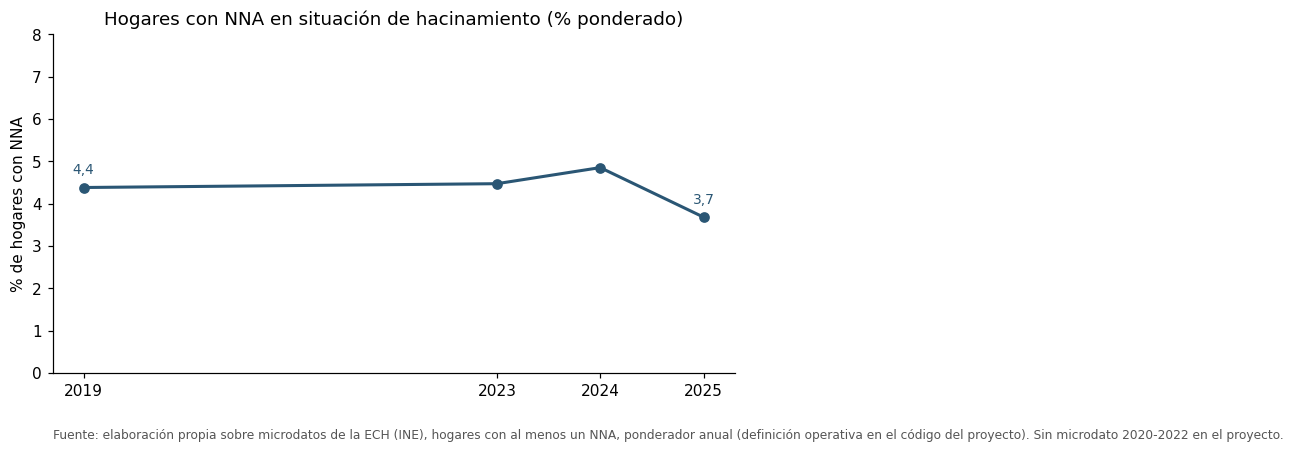

In [38]:
hac = ECHM[(ECHM["metrica"] == "hacinamiento_hogares_nna") & (ECHM["categoria"] == "total")].sort_values("anio")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hac["anio"], hac["valor"], marker="o", color=COLOR, linewidth=2)
ax.set_ylim(0, 8)
ax.set_xticks(hac["anio"])
ax.set_title("Hogares con NNA en situación de hacinamiento (% ponderado)")
ax.set_ylabel("% de hogares con NNA")
anotar_extremos(ax, hac["anio"].to_numpy(), hac["valor"].to_numpy(), COLOR, dec=1)
fuente(fig, "Fuente: elaboración propia sobre microdatos de la ECH (INE), hogares con al menos un NNA, "
            "ponderador anual (definición operativa en el código del proyecto). Sin microdato 2020-2022 en el proyecto.")
plt.show()

**Por qué esta gráfica.** Serie de cuatro mediciones reales: línea con
marcadores; los años ausentes son años sin extracción en el proyecto,
no ceros.

**Lectura**: el hacinamiento afecta a entre 3,7% y 4,9% de los hogares
con NNA según el año (3,7% en 2025, el valor más bajo de la serie). Su
apertura por departamento y tramo de edad queda disponible para el
análisis territorial.

### Métrica 33. Condiciones de la vivienda en hogares con NNA

**¿Qué pregunta responde?** ¿Qué carencias físicas tienen las viviendas
donde crecen los NNA?

**Advertencia de fuente**: la ECH relevó 12 carencias en 2019 y solo 4
desde 2024 (cambio del formulario del INE, heredado y documentado). Se
comparan únicamente las 4 presentes en ambos regímenes.

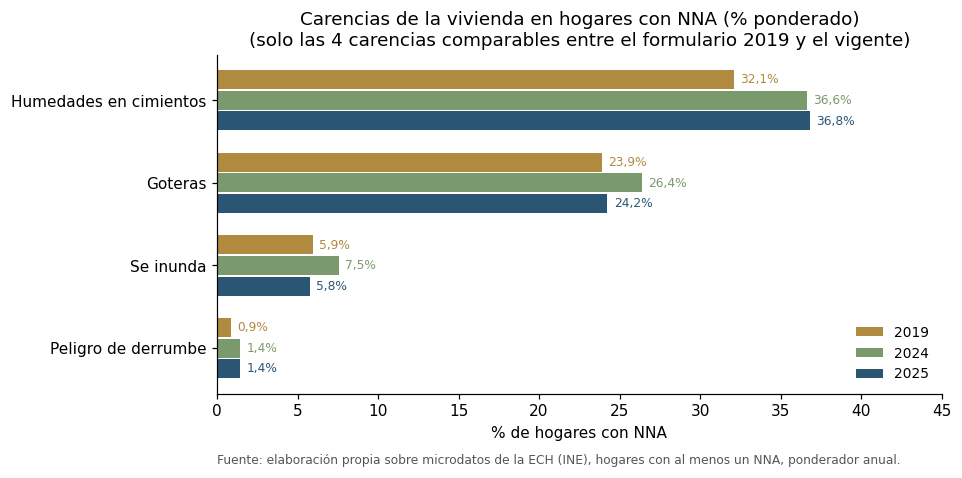

In [39]:
viv = ECHM[(ECHM["metrica"] == "vivienda_hogares_nna") &
           (ECHM["categoria"].str.startswith("carencia="))].copy()
viv["carencia"] = viv["categoria"].str.replace("carencia=", "", regex=False)
piv = viv.pivot_table(index="carencia", columns="anio", values="valor")
comunes = piv.dropna().sort_values(2025)
etiquetas = {"humedad_cimientos": "Humedades en cimientos", "goteras": "Goteras",
             "se_inunda": "Se inunda", "peligro_derrumbe": "Peligro de derrumbe"}
nombres = [etiquetas.get(c, c) for c in comunes.index]
y_pos = np.arange(len(comunes))
fig, ax = plt.subplots(figsize=(8.5, 4))
for i, (anio, color) in enumerate([(2019, PALETA[3]), (2024, PALETA[2]), (2025, COLOR)]):
    ax.barh(y_pos + 0.25 - i * 0.25, comunes[anio], height=0.23, color=color, label=str(anio))
    for j, v in enumerate(comunes[anio]):
        ax.annotate(pct(v), (v + 0.4, j + 0.25 - i * 0.25), fontsize=8, va="center", color=color)
ax.set_yticks(y_pos, nombres)
ax.set_xlim(0, 45)
ax.set_title("Carencias de la vivienda en hogares con NNA (% ponderado)\n"
             "(solo las 4 carencias comparables entre el formulario 2019 y el vigente)")
ax.set_xlabel("% de hogares con NNA")
ax.legend(frameon=False, fontsize=9)
fuente(fig, "Fuente: elaboración propia sobre microdatos de la ECH (INE), hogares con al menos un NNA, "
            "ponderador anual.", y=-0.05)
plt.show()

**Por qué esta gráfica.** Barras horizontales agrupadas por año: permite
comparar cada carencia entre años sin encadenar una serie que el cambio
de formulario no sostiene.

**Lectura**: las humedades en los cimientos son la carencia más
extendida (36,8% de los hogares con NNA en 2025, subiendo desde 32,1% en
2019) y las goteras afectan a un cuarto (24,2%). Más de un tercio de la
infancia uruguaya crece en viviendas con problemas de humedad
estructural.

### Métrica 34. Brecha digital en hogares con NNA

**¿Qué pregunta responde?** ¿Los hogares donde viven NNA tienen acceso a
internet y a dispositivos?

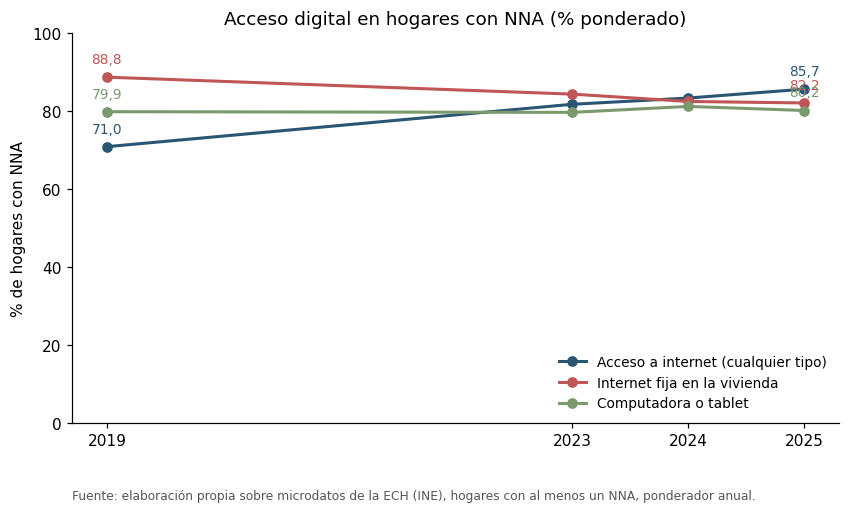

In [40]:
bd = ECHM[(ECHM["metrica"] == "brecha_digital_hogares_nna") &
          (ECHM["categoria"].isin(["recurso=internet", "recurso=internet_fija", "recurso=pc"]))].copy()
bd["recurso"] = bd["categoria"].str.replace("recurso=", "", regex=False)
piv = bd.pivot_table(index="anio", columns="recurso", values="valor")
fig, ax = plt.subplots()
nombres = {"internet": "Acceso a internet (cualquier tipo)", "internet_fija": "Internet fija en la vivienda",
           "pc": "Computadora o tablet"}
for i, col in enumerate(["internet", "internet_fija", "pc"]):
    ax.plot(piv.index, piv[col], marker="o", linewidth=2, color=PALETA[i], label=nombres[col])
    anotar_extremos(ax, piv.index.to_numpy(), piv[col].to_numpy(), PALETA[i], dec=1)
ax.set_ylim(0, 100)
ax.set_xticks(piv.index)
ax.set_title("Acceso digital en hogares con NNA (% ponderado)")
ax.set_ylabel("% de hogares con NNA")
ax.legend(frameon=False, fontsize=9, loc="lower right")
fuente(fig, "Fuente: elaboración propia sobre microdatos de la ECH (INE), hogares con al menos un NNA, "
            "ponderador anual.")
plt.show()

**Por qué esta gráfica.** Tres líneas de la misma unidad, eje 0-100;
los extremos anotados por recurso.

**Lectura**: el acceso general a internet crece (71,0% en 2019 → 85,7%
en 2025), pero la composición cambia: la internet **fija** en la
vivienda retrocede (88,8% → 82,2% entre los hogares con internet del
formulario de cada año) — consistente con la migración a conexiones
móviles — y la tenencia de computadora está estancada (~80%). La brecha
por estrato queda disponible en la fuente para el análisis
socioeconómico.

### Métrica 35. Inseguridad alimentaria en hogares con menores (FIES)

**¿Qué pregunta responde?** ¿Qué proporción de los hogares con menores
de 18 años experimenta inseguridad alimentaria?

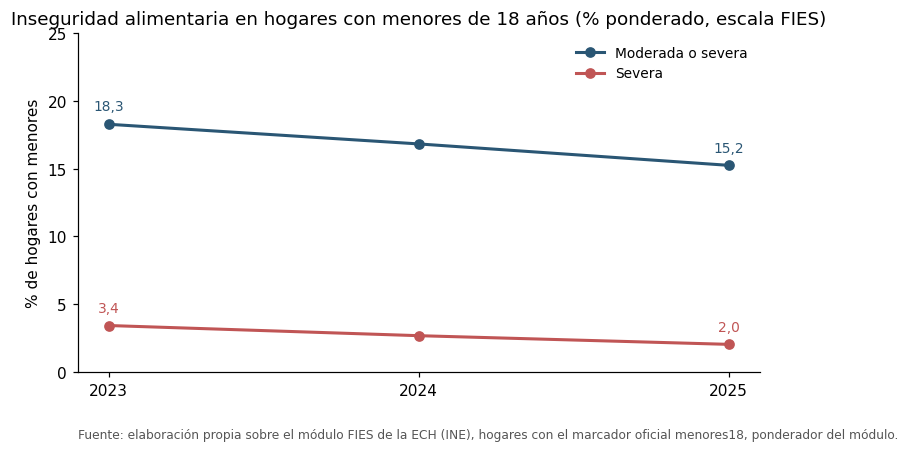

In [41]:
fies = ECHM[(ECHM["metrica"] == "fies_hogares_menores") &
            (ECHM["categoria"].isin(["nivel=moderada_o_severa", "nivel=severa"]))].copy()
piv = fies.pivot_table(index="anio", columns="categoria", values="valor")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(piv.index, piv["nivel=moderada_o_severa"], marker="o", color=COLOR, linewidth=2,
        label="Moderada o severa")
ax.plot(piv.index, piv["nivel=severa"], marker="o", color=ACENTO, linewidth=2, label="Severa")
anotar_extremos(ax, piv.index.to_numpy(), piv["nivel=moderada_o_severa"].to_numpy(), COLOR, dec=1)
anotar_extremos(ax, piv.index.to_numpy(), piv["nivel=severa"].to_numpy(), ACENTO, dec=1)
ax.set_ylim(0, 25)
ax.set_xticks(piv.index)
ax.set_title("Inseguridad alimentaria en hogares con menores de 18 años (% ponderado, escala FIES)")
ax.set_ylabel("% de hogares con menores")
ax.legend(frameon=False, fontsize=9)
fuente(fig, "Fuente: elaboración propia sobre el módulo FIES de la ECH (INE), hogares con el marcador "
            "oficial menores18, ponderador del módulo.")
plt.show()

**Por qué esta gráfica.** Dos niveles de la misma escala en líneas
separadas (no apiladas: «severa» es subconjunto de «moderada o
severa»).

**Lectura**: la inseguridad alimentaria moderada o severa desciende
(18,3% de los hogares con menores en 2023 → 15,3% en 2025), igual que la
severa (3,4% → 2,0%). Aun con la mejora, en 2025 unos 15 de cada 100
hogares con niños experimentaron inseguridad alimentaria — y en los
hogares con menores de 6 años la incidencia es levemente mayor (17,5%).

### Métrica 36. Victimización de hogares donde viven NNA

**¿Qué pregunta responde?** ¿Qué proporción de los hogares con NNA
sufrió delitos en el último año?

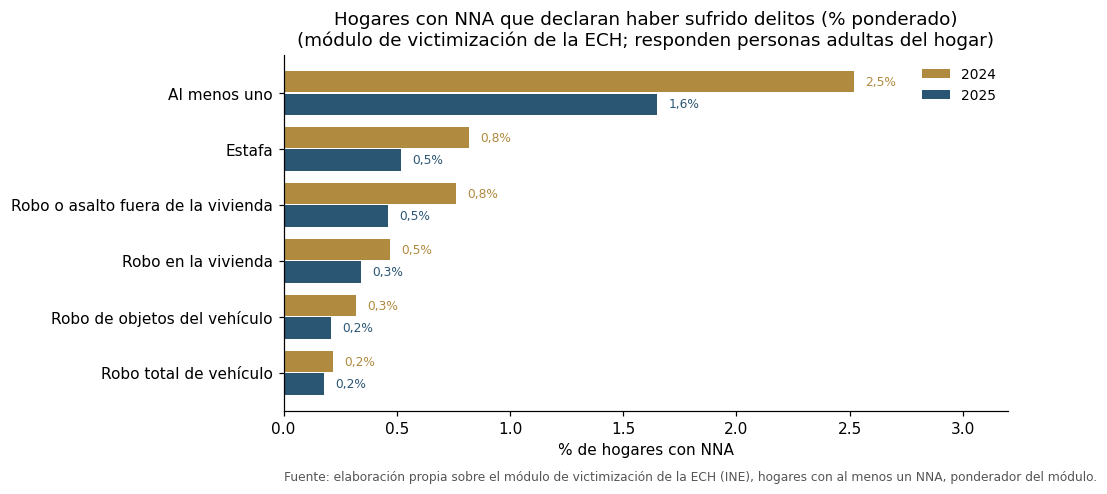

In [42]:
vic = ECHM[(ECHM["metrica"] == "victimizacion_hogares_nna") &
           (ECHM["categoria"].str.startswith("delito="))].copy()
vic["delito"] = vic["categoria"].str.replace("delito=", "", regex=False)
piv = vic.pivot_table(index="delito", columns="anio", values="valor").sort_values(2025)
y_pos = np.arange(len(piv))
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.barh(y_pos + 0.2, piv[2024], height=0.38, color=PALETA[3], label="2024")
ax.barh(y_pos - 0.2, piv[2025], height=0.38, color=COLOR, label="2025")
for i, (v24, v25) in enumerate(zip(piv[2024], piv[2025])):
    ax.annotate(pct(v24), (v24 + 0.05, i + 0.2), fontsize=8, va="center", color=PALETA[3])
    ax.annotate(pct(v25), (v25 + 0.05, i - 0.2), fontsize=8, va="center", color=COLOR)
ax.set_yticks(y_pos, piv.index)
ax.set_xlim(0, 3.2)
ax.set_title("Hogares con NNA que declaran haber sufrido delitos (% ponderado)\n"
             "(módulo de victimización de la ECH; responden personas adultas del hogar)")
ax.set_xlabel("% de hogares con NNA")
ax.legend(frameon=False, fontsize=9)
fuente(fig, "Fuente: elaboración propia sobre el módulo de victimización de la ECH (INE), hogares con al menos "
            "un NNA, ponderador del módulo.", y=-0.04)
plt.show()

**Por qué esta gráfica.** Barras horizontales agrupadas por año,
ordenadas por magnitud, para comparar tipos de delito con nombres
largos entre dos mediciones.

**Lectura**: 2,5% de los hogares con NNA declaró haber sufrido al menos
un delito en 2024, y 1,7% en 2025; el robo o asalto fuera de la
vivienda y la estafa encabezan los tipos. Serie nueva (el módulo se
releva desde 2024): su valor analítico crecerá con los años.

## Cruces entre fuentes — ¿La respuesta institucional sigue el mapa de la necesidad?

Los cuatro cruces del catálogo contrastan la respuesta de los sistemas
de protección (INAU, CONAPEES/Fiscalía, SIPIAV) y la única prevalencia
disponible (ENSANNA) con las condiciones socioeconómicas de la infancia
calculadas sobre la ECH. Reglas comunes a todos: ambos lados de cada
cruce al **mismo nivel de agregación**, lectura observacional
(asociación, nunca causa) y las limitaciones de cada cruce declaradas en
su propia sección — ninguna conclusión describe individuos.

### Cruce 1. ¿La intensidad territorial de la protección especial sigue el mapa de la pobreza infantil?

**¿Qué pregunta responde?** ¿Los departamentos con más pobreza infantil
son también los de mayor tasa de NNA en protección especial?

**Construcción**: tasa = NNA atendidos en proyectos del SPE del
departamento (segundo semestre de cada año) cada 1.000 NNA residentes
(población 0-17 ponderada de la ECH del mismo año). Advertencia
importante del numerador: cuenta dónde se **atiende** al NNA, no de
dónde proviene — un niño derivado a una residencia de otro departamento
cuenta en el departamento de la residencia.

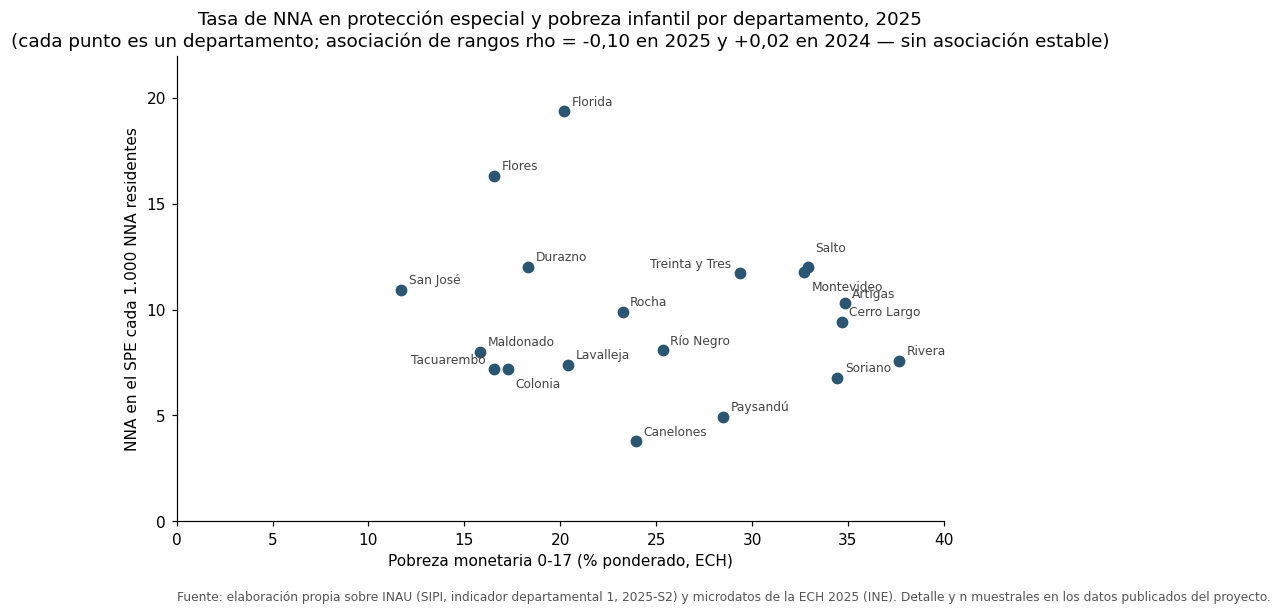

In [43]:
CRUCE = pd.read_csv(RESULTADOS / "cruces" / "cruce_inau_ech_departamental.csv")

c25 = CRUCE[CRUCE["anio"] == 2025]
rho25, _ = spearmanr(c25["tasa_spe_por_mil"], c25["pobreza_0a17_pct"])
c24 = CRUCE[CRUCE["anio"] == 2024]
rho24, _ = spearmanr(c24["tasa_spe_por_mil"], c24["pobreza_0a17_pct"])

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(c25["pobreza_0a17_pct"], c25["tasa_spe_por_mil"], color=COLOR, s=45, zorder=3)
a_la_izquierda = {"Treinta y Tres", "Tacuarembó"}
abajo = {"Montevideo", "Colonia"}
arriba = {"Salto"}
for _, fila in c25.iterrows():
    d = fila["departamento"]
    dx, dy, ha = 5, 4, "left"
    if d in a_la_izquierda:
        dx, ha = -6, "right"
    if d in abajo:
        dy = -12
    if d in arriba:
        dy = 10
    ax.annotate(d, (fila["pobreza_0a17_pct"], fila["tasa_spe_por_mil"]),
                textcoords="offset points", xytext=(dx, dy), ha=ha, fontsize=8, color="#444444")
ax.set_xlim(0, 40)
ax.set_ylim(0, 22)
ax.set_yticks(np.arange(0, 21, 5))
def _rho(v):
    return f"{v:+.2f}".replace(".", ",")
ax.set_title(
    "Tasa de NNA en protección especial y pobreza infantil por departamento, 2025\n"
    "(cada punto es un departamento; asociación de rangos "
    f"rho = {_rho(rho25)} en 2025 y {_rho(rho24)} en 2024 — sin asociación estable)"
)
ax.set_xlabel("Pobreza monetaria 0-17 (% ponderado, ECH)")
ax.set_ylabel("NNA en el SPE cada 1.000 NNA residentes")
fuente(fig, "Fuente: elaboración propia sobre INAU (SIPI, indicador departamental 1, 2025-S2) y microdatos "
            "de la ECH 2025 (INE). Detalle y n muestrales en los datos publicados del proyecto.",
       y=-0.02)
plt.show()

**Por qué esta gráfica.** Dispersión con los dos ejes en sus escalas
reales y cada departamento identificado: para una asociación entre dos
variables a nivel de 19 unidades, el plano completo con etiquetas es más
honesto que un coeficiente solo — el lector ve qué departamentos
sostienen (o desarman) la relación. El coeficiente de rangos (Spearman)
acompaña en el título con su valor en ambos años.

**Lectura**: **la intensidad territorial de la protección especial no
sigue el mapa de la pobreza infantil** (rho = −0,10 en 2025 y +0,02 en
2024: sin asociación, con signo inestable). Las tasas más altas están en
dos departamentos chicos de pobreza baja o media — Florida (19,4 por
mil, con 20,2% de pobreza infantil) y Flores (16,3 por mil, 16,6%) —
mientras que en el otro extremo conviven departamentos de pobreza
infantil alta con tasas bajas: Canelones (3,8 por mil, 23,9% de
pobreza), Paysandú (4,9 y 28,5%) y Rivera, que tiene la pobreza infantil
más alta del país (37,7%) y una tasa de 7,6. Con el hacinamiento el
resultado es el mismo (rho inestable entre −0,28 y +0,19). La interpretación prudente, en lenguaje observacional: la
distribución territorial de la atención parece responder a la
localización histórica de la oferta institucional (dónde hay residencias
y proyectos) y a derivaciones entre departamentos, más que a la
distribución territorial de la necesidad socioeconómica. Dos advertencias
acotan esta lectura: el numerador registra el departamento de atención
(no el de origen del NNA), y las estimaciones departamentales de la ECH
tienen error muestral mayor en los departamentos chicos (n muestrales en
el CSV del cruce). Aun con esas salvedades, la ausencia de correlación
es un hallazgo para la discusión de política territorial — y la pregunta
que abre (¿la oferta está donde está la necesidad?) excede lo que estas
fuentes pueden responder solas.

### Cruce 2. ¿La detección de la explotación sexual sigue el mapa de las carencias?

**¿Qué pregunta responde?** ¿Los departamentos con más pobreza infantil
y hacinamiento son también los de más situaciones de ESNNA atendidas
(CONAPEES) y más actuaciones fiscales por delitos sexuales contra NNA
(Fiscalía General de la Nación), en proporción a su población infantil?

**Construcción**: tasa cada 10.000 NNA = casos del departamento
(2018-2021, tablas 2 y 8 del estudio FLACSO 2023) sobre la población
0-17 ponderada de la ECH 2019 — el único año de la ventana con
microdatos extraídos; el lado socioeconómico (pobreza y hacinamiento)
queda fijo en 2019 por la misma razón, de modo que 2020 y 2021 se cruzan
contra condiciones previas a la pandemia. Tres advertencias mayores
acotan este cruce: los conteos departamentales son chicos (de 0 a 59
situaciones anuales en CONAPEES — una situación mueve la tasa de un
departamento chico), el registro mide detección y atención — nunca
incidencia — y el propio estudio FLACSO advierte que los departamentos
con más actuaciones cada 10.000 NNA posiblemente tienen más recursos y
equipos locales, no más explotación (pp. 46 y 52).

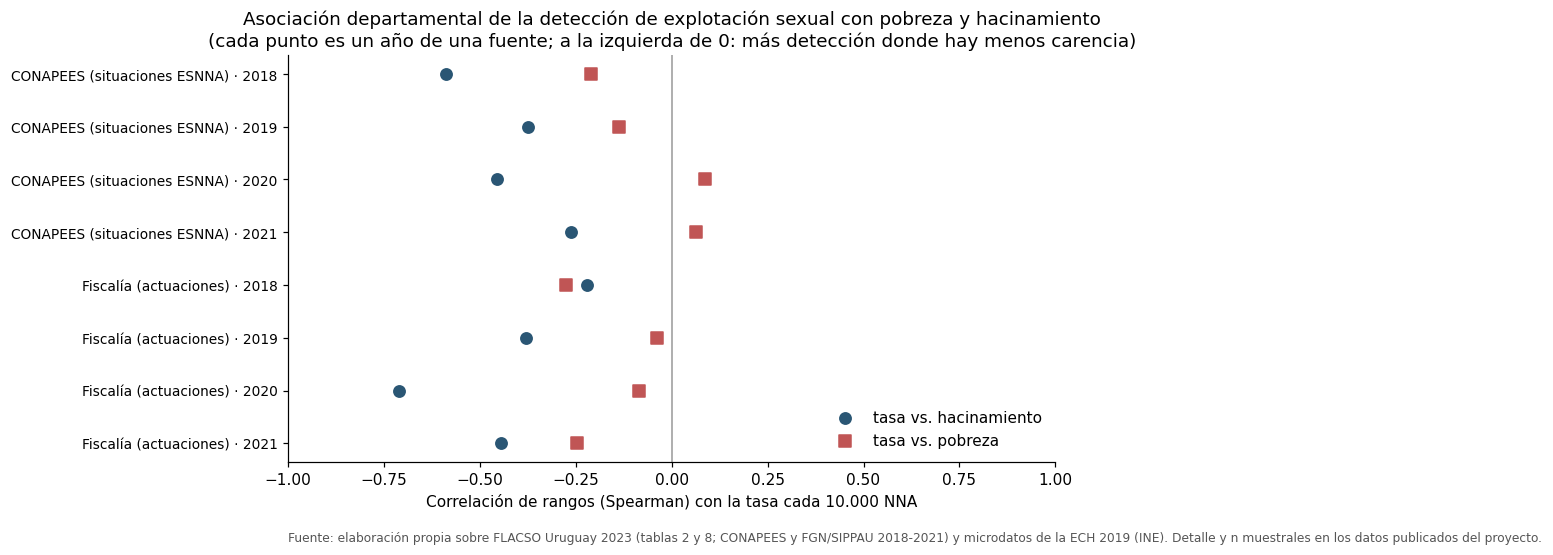

In [44]:
CFE = pd.read_csv(RESULTADOS / "cruces" / "cruce_conapees_fiscalia_ech.csv")

etiquetas_fuente = {"conapees": "CONAPEES (situaciones ESNNA)",
                    "fiscalia": "Fiscalía (actuaciones)"}
rhos = []
for fuente_cruce in ["conapees", "fiscalia"]:
    for anio_cruce in [2018, 2019, 2020, 2021]:
        t = CFE[(CFE["fuente"] == fuente_cruce) & (CFE["anio"] == anio_cruce)]
        for variable, etiqueta_v in [("pobreza_2019_pct", "pobreza"),
                                     ("hacinamiento_2019_pct", "hacinamiento")]:
            rho, _ = spearmanr(t["tasa_por_10mil"], t[variable])
            rhos.append({"fuente": etiquetas_fuente[fuente_cruce],
                         "anio": anio_cruce, "variable": etiqueta_v, "rho": rho})
RHOS = pd.DataFrame(rhos)

fig, ax = plt.subplots(figsize=(9, 4.8))
filas_y = [(f, a) for f in etiquetas_fuente.values() for a in [2018, 2019, 2020, 2021]]
posiciones = {fa: i for i, fa in enumerate(filas_y)}
for variable, color, marcador in [("hacinamiento", COLOR, "o"), ("pobreza", ACENTO, "s")]:
    sub = RHOS[RHOS["variable"] == variable]
    y = [posiciones[(f, a)] for f, a in zip(sub["fuente"], sub["anio"])]
    ax.scatter(sub["rho"], y, color=color, marker=marcador, s=55, zorder=3,
               label=f"tasa vs. {variable}")
ax.axvline(0, color="#999999", linewidth=1)
ax.set_yticks(range(len(filas_y)))
ax.set_yticklabels([f"{f} · {a}" for f, a in filas_y], fontsize=9)
ax.invert_yaxis()
ax.set_xlim(-1, 1)
ax.set_xlabel("Correlación de rangos (Spearman) con la tasa cada 10.000 NNA")
ax.set_title("Asociación departamental de la detección de explotación sexual con pobreza y hacinamiento\n"
             "(cada punto es un año de una fuente; a la izquierda de 0: más detección donde hay menos carencia)")
ax.legend(frameon=False, loc="lower right")
fuente(fig, "Fuente: elaboración propia sobre FLACSO Uruguay 2023 (tablas 2 y 8; CONAPEES y FGN/SIPPAU 2018-2021) y "
            "microdatos de la ECH 2019 (INE). Detalle y n muestrales en los datos publicados del proyecto.")
plt.show()

**Por qué esta gráfica.** Con dos fuentes, cuatro años y dos variables,
mostrar el plano de un solo año sería una selección arbitraria: se
muestra el coeficiente de cada combinación (16 puntos) para exhibir lo
único que este cruce puede afirmar con honestidad — la estabilidad del
signo a través de años y fuentes. El detalle departamental, con sus n
muestrales, queda en el CSV del cruce.

**Lectura**: con la pobreza no hay asociación (rho entre −0,27 y +0,09
según año y fuente, siempre compatible con el azar). Con el hacinamiento
la asociación es **negativa en las ocho combinaciones** (entre −0,22 y
−0,71): los departamentos con más hacinamiento tienden a registrar
*menos* situaciones atendidas y menos actuaciones fiscales cada 10.000
NNA, no más. Leída junto con la advertencia del propio estudio FLACSO —
más actuaciones donde hay más recursos y equipos, no necesariamente más
incidencia — la interpretación observacional prudente es que este cruce
retrata la **geografía de la capacidad de detección, no la del
fenómeno**: donde las carencias habitacionales son mayores, el sistema
registra menos. Advertencias adicionales: el valor de Paysandú 2020 en
la fuente fiscal (1 actuación) es una anomalía interna del estudio — el
resultado se sostiene al excluirlo (rho = −0,66) — y el numerador
registra el departamento de actuación, no el de residencia de la
víctima.

### Cruce 3. ¿El trabajo infantil sigue el gradiente socioeconómico de la pobreza?

**¿Qué pregunta responde?** ¿El trabajo infantil declarado (la única
prevalencia real del proyecto) se concentra en los niveles
socioeconómicos bajos tanto como la pobreza infantil?

**Construcción**: este cruce compara **formas de gradiente, no
valores** — las escalas socioeconómicas de los dos lados no son la misma
variable. La ENSANNA clasifica por INSE (índice de CINVE, nacional,
cinco niveles); la extracción de la ECH solo trae un ordenamiento
socioeconómico comparable para Montevideo (estratos 1 a 5 — los códigos
del interior son geográficos, sin orden socioeconómico). A eso se suman
universos distintos (5-17 contra 0-17) y que el boletín ENSANNA no
publica errores estándar ni microdatos. Por eso los paneles llevan
escalas separadas y ninguna cifra de un lado se compara con el nivel del
otro.

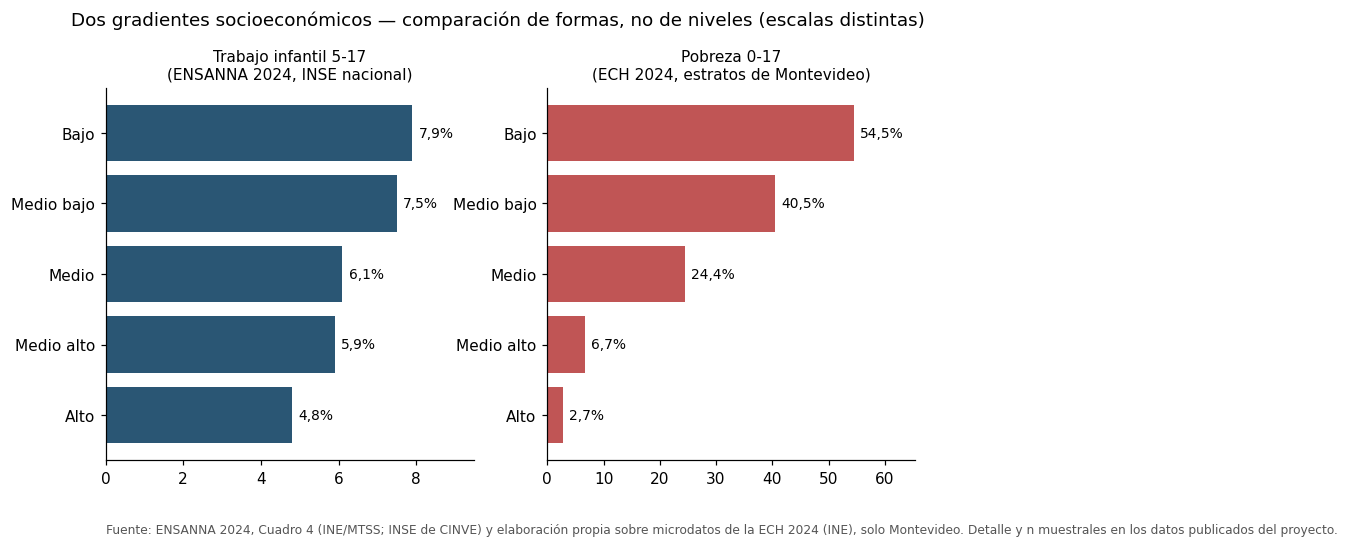

In [45]:
CEE = pd.read_csv(RESULTADOS / "cruces" / "cruce_ensanna_ech.csv")
orden_nse = ["Bajo", "Medio bajo", "Medio", "Medio alto", "Alto"]
ens_nse = (CEE[(CEE["fuente"] == "ensanna_2024") & (CEE["dimension"] == "nse")
               & (CEE["metrica"] == "trabajo_infantil")]
           .set_index("categoria").loc[orden_nse, "valor"])
ech_nse = (CEE[(CEE["fuente"] == "ech_2024") & (CEE["dimension"] == "nse")]
           .set_index("categoria").loc[orden_nse, "valor"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4.4))
for ax, serie, titulo, color in [
    (ax1, ens_nse, "Trabajo infantil 5-17\n(ENSANNA 2024, INSE nacional)", COLOR),
    (ax2, ech_nse, "Pobreza 0-17\n(ECH 2024, estratos de Montevideo)", ACENTO),
]:
    ax.barh(range(len(serie)), serie.to_numpy(), color=color)
    ax.set_yticks(range(len(serie)))
    ax.set_yticklabels(serie.index)
    ax.invert_yaxis()
    ax.set_title(titulo, fontsize=10)
    for i, v in enumerate(serie):
        ax.annotate(pct(v), (v, i), textcoords="offset points", xytext=(4, 0),
                    va="center", fontsize=9)
    ax.set_xlim(0, serie.max() * 1.2)
fig.suptitle("Dos gradientes socioeconómicos — comparación de formas, no de niveles (escalas distintas)",
             y=1.04, fontsize=12)
fuente(fig, "Fuente: ENSANNA 2024, Cuadro 4 (INE/MTSS; INSE de CINVE) y elaboración propia sobre microdatos de la "
            "ECH 2024 (INE), solo Montevideo. Detalle y n muestrales en los datos publicados del proyecto.")
plt.show()

**Por qué esta gráfica.** Dos paneles de barras con escalas separadas:
la única comparación defendible entre dos índices socioeconómicos
distintos es la forma del gradiente (¿es monótono? ¿cuánto separa a los
extremos?), y esa forma se ve en los largos relativos de las barras de
cada panel, sin inducir jamás la comparación de niveles entre paneles.

**Lectura**: los dos gradientes son monótonos — a menor nivel
socioeconómico, más trabajo infantil y más pobreza — pero sus pendientes
relativas son muy distintas: la pobreza infantil de Montevideo se
multiplica por 20 entre el estrato alto y el bajo (2,7% a 54,5%),
mientras el trabajo infantil nacional apenas se multiplica por 1,6 (4,8%
a 7,9%). En términos observacionales: **el trabajo infantil declarado
atraviesa toda la estructura social** y su gradiente es mucho más plano
que el de la pobreza. La región refuerza esa disociación con dos fuentes
independientes: el trabajo infantil 5-17 es más frecuente en el interior
que en Montevideo (7,7% contra 5,2%, y el doble en actividades
económicas: 5,9% contra 2,9%), igual que la ocupación adolescente 14-17
medida por la ECH (3,7% contra 1,7%) — pero la pobreza infantil es algo
mayor en Montevideo (30,9% contra 27,8% en 2024). **La geografía del
trabajo infantil no es la geografía de la pobreza infantil**: el
componente rural y de actividades económicas del interior pesa más que
la privación monetaria. Advertencia final: la ENSANNA mide actividades
declaradas por los hogares, y la subdeclaración no es necesariamente
pareja entre niveles socioeconómicos.

### Cruce 4. ¿Las edades atendidas por el SIPIAV reflejan las edades de la población infantil?

**¿Qué pregunta responde?** ¿Qué tramos de edad pesan en las situaciones
de violencia atendidas más de lo que pesan en la población — y ese
sesgo, sigue al tramo más pobre?

**Construcción**: índice de representación = participación del tramo en
las situaciones atendidas (SIPIAV, distribución publicada, renormalizada
al universo 0-17) sobre su participación en la población 0-17 (ECH
ponderada del mismo año). 1 = el tramo pesa en la atención lo mismo que
en la población. Años comparables: 2019 y 2025, los únicos con la
distribución etaria completa y microdatos ECH extraídos. El SIPIAV no
publica apertura departamental, así que este cruce es solo nacional
(limitación estructural del catálogo).

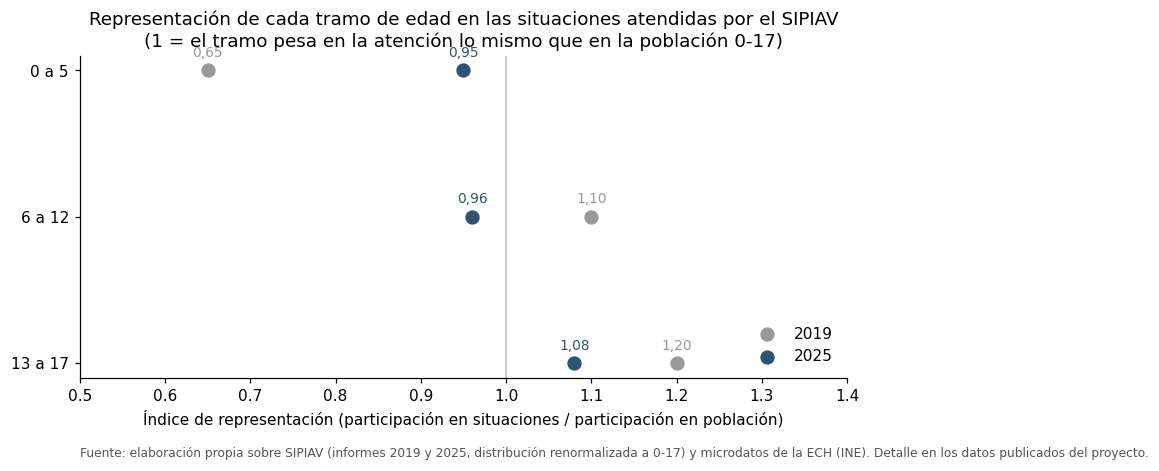

In [46]:
CSE = pd.read_csv(RESULTADOS / "cruces" / "cruce_sipiav_ech_tramos.csv")
tramos_cruce = ["0 a 5", "6 a 12", "13 a 17"]
fig, ax = plt.subplots(figsize=(9, 3.8))
for anio_cruce, color in [(2019, "#999999"), (2025, COLOR)]:
    t = CSE[CSE["anio"] == anio_cruce].set_index("tramo").loc[tramos_cruce]
    ax.scatter(t["indice_representacion"], range(len(tramos_cruce)), s=70,
               color=color, zorder=3, label=str(anio_cruce))
    for i, v in enumerate(t["indice_representacion"]):
        ax.annotate(f"{v:.2f}".replace(".", ","), (v, i),
                    textcoords="offset points", xytext=(0, 9), ha="center",
                    fontsize=9, color=color)
ax.axvline(1, color="#bbbbbb", linewidth=1)
ax.set_yticks(range(len(tramos_cruce)))
ax.set_yticklabels(tramos_cruce)
ax.invert_yaxis()
ax.set_xlim(0.5, 1.4)
ax.set_xlabel("Índice de representación (participación en situaciones / participación en población)")
ax.set_title("Representación de cada tramo de edad en las situaciones atendidas por el SIPIAV\n"
             "(1 = el tramo pesa en la atención lo mismo que en la población 0-17)")
ax.legend(frameon=False, loc="lower right")
fuente(fig, "Fuente: elaboración propia sobre SIPIAV (informes 2019 y 2025, distribución renormalizada a 0-17) y "
            "microdatos de la ECH (INE). Detalle en los datos publicados del proyecto.", y=-0.08)
plt.show()

**Por qué esta gráfica.** El índice de representación en un eje único
con la línea de paridad marcada: la pregunta del cruce es de desvío
respecto de 1, y esa distancia se lee directamente, con los dos años
como control de estabilidad.

**Lectura**: los adolescentes (13-17) están sobrerrepresentados en las
situaciones atendidas en ambos años (índice 1,20 en 2019 y 1,08 en
2025). El cambio grande es la primera infancia: pasó de una
subrepresentación fuerte en 2019 (0,65) a la casi paridad en 2025
(0,95). El registro no permite distinguir si eso refleja más violencia
hacia la primera infancia o mejor detección temprana — y el informe
SIPIAV 2025 introdujo además una metodología nueva en paralelo, con
quiebres documentados en la serie curada. Lo que el cruce sí permite
afirmar: **el perfil etario de la atención no sigue al de la pobreza** —
la primera infancia es el tramo más pobre en ambos años (29,1% contra
26,5% de los adolescentes en 2025) y aun así fue el tramo históricamente
menos representado en la atención. La sobrerrepresentación adolescente
es coherente con la mayor visibilidad de esa violencia para el sistema
(escolarización, capacidad de denuncia propia), no necesariamente con
mayor incidencia. Advertencias: porcentajes publicados redondeados a
enteros y renormalizados (2019 incluía un 9% de mayores de 18) y quiebre
de tramos en 2020 (0-3/4-5 pasa a 0-5): la comparación usa el agregado
0-5, único comparable.

## Contexto transversal — La demografía detrás de todas las tasas

### P6. Población de 0 a 17 años de Uruguay, proyección oficial

**¿Qué pregunta responde?** ¿Cómo evoluciona el denominador de todas las
tasas de infancia del país?

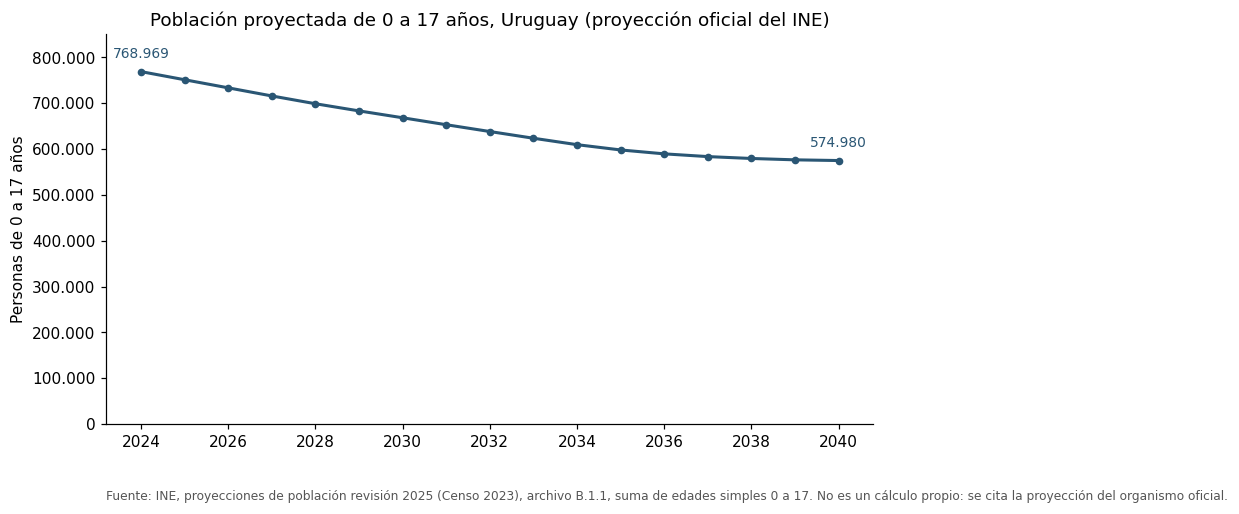

In [47]:
import openpyxl

wb = openpyxl.load_workbook(DATA / "ine" / "proyecciones_rev2025" / "B11_uruguay_edad_simple_2024_2070.xlsx",
                            read_only=True)
filas = list(wb["Uruguay"].iter_rows(values_only=True))
wb.close()
encabezado = filas[4]
cols = {a: i for i, a in enumerate(encabezado) if isinstance(a, int) and a <= 2040}
anios_ine = sorted(cols)
pob017 = [sum(filas[6 + edad][cols[a]] for edad in range(18)) for a in anios_ine]

fig, ax = plt.subplots()
ax.plot(anios_ine, pob017, marker="o", color=COLOR, linewidth=2, markersize=4)
ax.set_ylim(0, 850000)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt(v)))
ax.set_title("Población proyectada de 0 a 17 años, Uruguay (proyección oficial del INE)")
ax.set_ylabel("Personas de 0 a 17 años")
anotar_extremos(ax, anios_ine, pob017, COLOR)
fuente(fig, "Fuente: INE, proyecciones de población revisión 2025 (Censo 2023), archivo B.1.1, suma de "
            "edades simples 0 a 17. No es un cálculo propio: se cita la proyección del organismo oficial.")
plt.show()

**Por qué esta gráfica.** Línea sobre la proyección del organismo
productor (única proyección del informe que no es propia): se cita, no
se modela.

**Lectura**: la población de 0 a 17 años cae de 768.969 (2024) a menos
de 600.000 hacia 2040 según la revisión 2025 del INE — más de un quinto
menos en una década y media. Toda tasa «cada 1.000 NNA» del país subirá
mecánicamente si su numerador no cae al mismo ritmo (el caso de P4), y
todo servicio dimensionado para la infancia actual operará sobre una
población menguante: es el trasfondo demográfico de todos los temas de
este informe.

## Nota metodológica

**Registros administrativos y prevalencia.** La mayoría de las cifras de
este informe (SIPIAV, CONAPEES, Fiscalía, INAU) cuentan las situaciones
que cada sistema detecta y atiende. No miden cuántos NNA atraviesan cada
problema: un aumento puede reflejar mayor capacidad de detección, más
denuncia o más incidencia, y el registro solo no permite distinguirlo.
Por eso ninguna frase de este informe convierte cifras de registro en
afirmaciones sobre la magnitud del fenómeno. Las únicas fuentes de
prevalencia son la ENSANNA 2024 y los cálculos propios sobre la ECH.

**Qué significa «ponderado».** Las cifras de encuestas no son
porcentajes simples de las personas encuestadas: cada hogar de la
muestra representa a un número distinto de hogares del país. Todos los
porcentajes de encuesta de este informe usan esa expansión.

**Escenarios inerciales.** Las proyecciones describen qué sucedería **si
las condiciones actuales persisten**, siempre con un rango. No son
pronósticos. Cuando ningún modelo simple supera la prueba de validación
(el caso de P4), no se publica proyección — se dice explícitamente. La
justificación técnica de cada método, con sus pruebas, está publicada
en el repositorio del proyecto y no forma parte de este informe.

**Quiebres de serie.** Ninguna serie con cambio de definición o de
metodología se presenta empalmada: los quiebres se marcan en la propia
gráfica (tipos de violencia 2020 y 2024, base de cálculo SIPIAV 2025,
canasta de pobreza 2023-2024, formulario de vivienda) y los puntos no
comparables se dibujan sueltos.

**Celdas chicas y datos faltantes.** No se publica ninguna
desagregación por debajo del umbral que publica el propio organismo, y
las categorías de datos faltantes se muestran cuando la fuente las
publica (métrica 26): la calidad del registro es parte del dato.

## Resumen analítico

**Violencia (SIPIAV).** La respuesta del sistema se multiplicó por 7 en doce años (1.319 → 9.178 situaciones). Entre 54% y 56% de las situaciones corresponde a niñas y adolescentes mujeres, estable en toda la serie. Las edades escolares concentran el registro (72 de cada 100 situaciones entre los 6 y los 17 años en 2025). El maltrato emocional encabeza los tipos registrados en toda la serie, con quiebres de clasificación (2020 y 2024) marcados sin interpolar. Las violencias sexuales tienen patrón propio: 76% niñas y adolescentes mujeres, 51% concentrado en 13-17 años. La mayoría de las situaciones ya eran recurrentes al ser detectadas, en toda la serie comparable. La detección sigue siendo tardía: en la serie comparable, alrededor de 9 de cada 10 situaciones ya eran crónicas. Alrededor de 9 de cada 10 personas agresoras integran el entorno familiar o de convivencia del NNA. Solo alrededor de 4 de cada 10 NNA atendidos visualiza la violencia que sufre. La inclusión de la familia en la intervención cayó de 82% a 58% en una década. La cobertura territorial llegó a 36 Comités de Recepción Local, con señales de acercarse a su techo. La proyección de situaciones publicada para 2025 quedó validada por el dato real. De continuar la tendencia, hacia 2027 la familia se incluiría en aproximadamente la mitad de las intervenciones. De seguir el ritmo de aperturas, el sistema sumaría unos tres comités hacia 2028.

**Explotación sexual (CONAPEES/Fiscalía).** Entre 240 y 494 situaciones atendidas por año (2018-2021), sin serie oficial desde 2022. 86% de las víctimas identificadas son niñas y adolescentes mujeres. Desde 2024 la explotación sexual perdió su categoría propia en el registro del SIPIAV. Más de 2.000 actuaciones anuales de la Fiscalía por delitos sexuales con víctima NNA.

**Trabajo infantil (ENSANNA/ECH).** 6,8% de los NNA de 5 a 17 (40.200) está en situación de trabajo infantil, con gradientes por edad, región y nivel socioeconómico. El trabajo no remunerado de servicios ya muestra división sexual (niñas 2,8% frente a varones 1,1%). La comparación honesta con 2010 es un rango: el trabajo infantil habría descendido desde entre 9,9% y 13,4% hasta 6,8%. El trabajo adolescente que existe es casi todo informal (82-93% de los ocupados de 14-17).

**Protección especial (INAU).** El sistema creció hasta 2023 y se amesetó (~8.000 atendidos; ~7.000 de 0-17). La desinternación avanza: de 50,9% a 62,7% de los NNA del sistema en contexto familiar. La demanda nueva domina la puerta de entrada: entre 21% y 26% de los atendidos ingresa por primera vez cada año. El sistema egresa cada año a alrededor de un cuarto de su población atendida. Entre 25% y 32% de los atendidos pasa cada año de residencia a un entorno familiar. Solo entre 15% y 18% de los NNA con condición de adoptabilidad pasa cada año a seguimiento de tenencia. 56,9% de los casos no tiene registro del contacto familiar: la calidad del registro es el límite del dato. Aun dentro del sistema, cerca de 1 de cada 10 NNA de 6 a 17 no está inscripto en educación formal. Casi 4 de cada 10 NNA del sistema no tienen los controles médicos al día, y más de 2 de cada 10, las vacunas. El acogimiento familiar se apoya sobre todo en la red del propio NNA (familia extensa y por afinidad). La fotografía de abril de 2025 muestra que la mayoría de los NNA acompañados vive en entornos familiares. De persistir el ritmo, la desinternación llegaría a 66,4% de NNA en contexto familiar hacia 2027. La tasa de NNA en protección (9,4 por mil) sube por pura demografía: la población de 0 a 17 cae 2,3% por año.

**Pobreza y entorno (ECH).** 27,5% de los NNA en hogares pobres (2025, canasta 2017), con la primera infancia como el grupo más afectado. El hacinamiento afecta a entre 3,7% y 4,9% de los hogares con NNA según el año. Más de un tercio de los hogares con NNA tiene humedades estructurales. La brecha digital se cierra en acceso general pero retrocede en internet fija. La inseguridad alimentaria mejora pero alcanza al 15,3% de los hogares con menores. 2,5% de los hogares con NNA declaró haber sufrido al menos un delito en 2024 — serie nueva, relevada desde ese año.

**Cruces entre fuentes (contra la ECH).** La tasa departamental de protección especial no está asociada a la pobreza infantil ni al hacinamiento: la distribución territorial de la atención parece responder a la oferta institucional más que al mapa de la necesidad. La detección de la explotación sexual tampoco sigue el mapa de las carencias: se registra menos donde el hacinamiento es mayor, en las ocho combinaciones de fuente y año. El trabajo infantil declarado atraviesa toda la estructura social, con un gradiente mucho más plano que el de la pobreza y la geografía invertida. El perfil etario de la atención del SIPIAV no sigue al tramo más pobre: la primera infancia fue históricamente la menos representada, aunque en 2025 se acercó a la paridad.

## Conclusiones

1. **La pobreza uruguaya está concentrada en la infancia, y dentro de la
   infancia, en sus edades más tempranas.** 27,5% de los NNA en hogares
   pobres (2025) frente a ~17% en la población general, con incidencia
   máxima en la primera infancia. Es el dato más relevante del informe
   para el diseño de políticas (fuente: elaboración propia sobre ECH,
   INE).

2. **El país tiene sistemas de protección en expansión y una infancia en
   contracción.** La respuesta del SIPIAV se multiplicó por 7; el SPE
   del INAU creció hasta amesetarse en ~8.000 atendidos; y la población
   de 0 a 17 cae 2,3% por año. La combinación produce tasas de
   institucionalización crecientes aun sin crecimiento de los sistemas
   (P4) — leer cualquier tasa de infancia sin su denominador demográfico
   induce a error (fuentes: SIPIAV, INAU, INE).

3. **La detección de la violencia llega tarde y la intervención pierde a
   la familia.** En la serie comparable, ~9 de cada 10 situaciones
   detectadas ya eran crónicas, solo 4 de cada 10 NNA visualizan la
   violencia que sufren, y la inclusión familiar en la intervención cayó
   24 puntos en una década (82% → 58%), con escenario inercial en ~50%
   hacia 2027 (fuente: SIPIAV).

4. **La violencia sexual hacia NNA es adolescente y de género, y perdió
   visibilidad estadística.** 76% de las violencias sexuales afecta a
   niñas y adolescentes mujeres y 51% se concentra en 13-17 años; la
   explotación sexual no tiene serie oficial desde 2022 y desde 2024
   quedó fusionada dentro de «violencias sexuales» (fuentes: SIPIAV,
   CONAPEES/FLACSO).

5. **Uruguay no mide la prevalencia de la violencia hacia NNA.** Todo el
   tema 1 es registro administrativo. La única aproximación existente —
   una encuesta de 2026 de UNICEF con muestra no probabilística, que
   sugiere que cerca de 3 de cada 10 jóvenes vivió violencia sexual
   antes de los 18 — no sustituye una medición oficial con diseño
   muestral: esa es la brecha de información más importante que este
   proyecto identifica (fuentes: SIPIAV; UNICEF/Equipos 2026, con su
   diseño declarado).

**Limitaciones declaradas de este informe**: (a) las cifras de
registros administrativos describen la respuesta de los sistemas, no
la prevalencia; (b) las proyecciones son escenarios inerciales con
supuesto explícito — y donde ningún modelo pasó la validación (P4) no
hay proyección; (c) los microdatos de la ENSANNA aún no son públicos
(el tema 3 usa el boletín oficial); (d) el SIPIAV no publica
desagregación departamental, lo que limita el análisis territorial de
la violencia; (e) los cuatro cruces entre fuentes comparten tres
límites estructurales — los numeradores administrativos registran
dónde se atiende o actúa (no dónde reside el NNA), las estimaciones
departamentales de la ECH tienen error muestral mayor en los
departamentos chicos, y toda asociación es observacional — además de
las limitaciones propias declaradas en la sección de cada cruce:
escalas socioeconómicas no comparables y sin errores estándar en la
ENSANNA, porcentajes redondeados y renormalizados en el SIPIAV, y
conteos chicos con condiciones fijadas en 2019 en CONAPEES/Fiscalía.

## Fuentes de datos y bibliografía

Cada cifra de este informe lleva su fuente citada en su propia sección.
Esta última sección reúne, para verificación directa, las fuentes de
datos con su dirección completa y las referencias que respaldan las
decisiones de método y de gráfica.

### Fuentes de datos

**Registros administrativos e informes institucionales**

- **SIPIAV — informes de gestión (serie desde 2013)**, INAU y sistema
  interinstitucional. Registro administrativo: mide situaciones
  atendidas, nunca prevalencia.
  <https://www.inau.gub.uy/sipiav>
- **INAU — indicadores del Sistema de Protección Especial (SIPI)**,
  nacionales y departamentales. Registro administrativo.
  <https://inau.gub.uy/transparencia/indicadores-sistema-de-proteccion-especial-inau>
- **CONAPEES — explotación sexual de niñas, niños y adolescentes**.
  <https://www.inau.gub.uy/conapees>
- **FLACSO Uruguay (2023) — *Explotación sexual hacia niñas, niños y
  adolescentes***, capítulo 6: serie cuantitativa 2018-2021 de CONAPEES
  y actuaciones de la Fiscalía General de la Nación (SIPPAU).
  <https://flacso.edu.uy/wp-content/uploads/2023/12/EXPLOTACION-SEXUAL-HACIA-NINAS-NINOS-Y-ADOLESCENTES-COMPLETO.pdf>
- **CETI — política nacional contra el trabajo infantil (MTSS)**.
  <https://www.gub.uy/ministerio-trabajo-seguridad-social/comunicacion/noticias/ceti>

**Encuestas y estadísticas oficiales (INE)**

- **ENSANNA 2024 — Encuesta Nacional sobre las Actividades de Niñas,
  Niños y Adolescentes** (INE/MTSS). Única fuente de prevalencia del
  informe.
  <https://www.gub.uy/instituto-nacional-estadistica/datos-y-estadisticas/encuestas/encuesta-nacional-sobre-actividades-ninas-ninos-adolescentes-ensanna>
- **ECH — Encuesta Continua de Hogares (INE)**, microdatos ponderados
  (pobreza, hacinamiento, vivienda, brecha digital, empleo adolescente,
  seguridad alimentaria y victimización). Catálogo ANDA:
  <https://www4.ine.gub.uy/Anda5/>
- **Proyecciones de población, revisión 2025 (INE, Censo 2023)** — el
  denominador demográfico de todas las tasas.
  <https://www.gub.uy/instituto-nacional-estadistica/proyeccionesrev2025>

**Fuentes secundarias**

- **UNICEF Uruguay — Infancia en Datos** (pobreza infantil, protección).
  <https://www.unicef.org/uruguay/infancia-en-datos>

### Bibliografía que respalda las decisiones de gráfica

- **Cleveland, W.S. & McGill, R. (1984).** "Graphical Perception: Theory,
  Experimentation, and Application to the Development of Graphical
  Methods". *Journal of the American Statistical Association*, 79(387),
  531-554. Fundamento de la comparación de longitudes desde una base
  común (barras) y de las series en escala real, frente a
  codificaciones menos precisas como el área o el ángulo.
- **Healy, K. (2018).** *Data Visualization: A Practical Introduction*.
  Princeton University Press. Integridad visual del eje y la escala: no
  truncar el eje vertical de un conteo ni comprimir la escala completa
  de un porcentaje.
- **Tufte, E.R. (1983).** *The Visual Display of Quantitative
  Information*. Graphics Press. Principio de *data-ink ratio*: cada
  elemento visual del informe existe para transportar un dato.

### Bibliografía que respalda el método

- **Hyndman, R.J. & Athanasopoulos, G.** *Forecasting: Principles and
  Practice* (3ª ed.). OTexts. Fundamento del protocolo predictivo de
  este informe: candidatos simples, horizonte acotado al largo de la
  serie, rangos derivados de los residuos y validación fuera de muestra.
  <https://otexts.com/fpp3/>
- **Makridakis, S., Spiliotis, E. & Assimakopoulos, V. (2018).**
  "Statistical and Machine Learning forecasting methods: Concerns and
  ways forward". *PLOS ONE*, 13(3). Evidencia de que en series cortas
  los métodos estadísticos simples superan a los de aprendizaje
  automático — por eso las proyecciones no usan modelos complejos.
  <https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0194889>
- **Shmueli, G. (2010).** "To Explain or to Predict?". *Statistical
  Science*, 25(3), 289-310. Distinción entre modelar para explicar y
  modelar para predecir: fundamento de que las proyecciones de este
  informe describan trayectorias sin afirmar causas.
  <https://projecteuclid.org/journals/statistical-science/volume-25/issue-3/To-Explain-or-to-Predict/10.1214/10-STS330.full>

La bibliografía completa del proyecto —con la naturaleza de cada dato,
sus advertencias de uso y el respaldo textual de cada valor de las
series curadas— es pública y está en el repositorio:
<https://github.com/testa10/agente-politicas-sociales>

---

*Informe generado por el proyecto*
[agente-politicas-sociales](https://github.com/testa10/agente-politicas-sociales).